<a href="https://colab.research.google.com/github/NikitaMarnykh/labor_market_analysis/blob/main/%D0%9C%D0%B0%D1%80%D0%BD%D1%8B%D1%85_%D0%9D_%D0%92_%D0%B8_%D0%9E%D0%B1%D0%BE%D1%80%D0%BE%D1%82%D0%BE%D0%B2_%D0%9C_%D0%92_%D1%80%D1%8B%D0%BD%D0%BE%D0%BA_%D1%82%D1%80%D1%83%D0%B4%D0%B0_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Признаки, которые будут использованы для дальнейшего анализа**

Количественные признаки:
  
  - идентификатор вакансии (id)

  - минимальная заработная плат (salary_from)
  
  - максимальная заработная плата (salary_to)

Категориальные признаки:

  - профессиональная роль (professional roles)

  - ключевые навыки (key_skills)

  - наименование работодателя (employer)

  - опыт работы (experience)

  - график работы (schedule)

  - тип занятости (employment)

  - доступна ли вакансия для соискателей с инвалидностью (accept_handicapped)

  - город (city)

  - сфера деятельности (field_of_activity)

## 6. Установка и подключение зависимостей для анализа данных

Устанавливаем все необходимые зависимости

In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install seaborn

Подключаем все необходимые зависимости

In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as stats

import seaborn as sns

Подгружаем репозиторий для работы с ним

In [3]:
!git clone https://github.com/NikitaMarnykh/labor_market_analysis

Cloning into 'labor_market_analysis'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 112 (delta 68), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 69.97 MiB | 7.67 MiB/s, done.
Resolving deltas: 100% (68/68), done.


Перейдём в установленный репозиторий

In [4]:
%cd labor_market_analysis/

/content/labor_market_analysis


Сохраним датасет в переменную

In [5]:
dataset = pd.read_csv('cleaned_hh_hard.csv',
                      na_values=['NA', 'N/A', 'null', 'missing', '-', '?', '...'],
                      dtype={
                             'id': 'Int64', 'professional_roles': 'string',
                             'experience': 'category', 'schedule': 'category',
                             'employment': 'category', 'employer': 'string',
                             'accept_handicapped': 'category', 'key_skills': 'string',
                             'city': 'string', 'salary_from': 'Int64',
                             'salary_to': 'Int64', 'field_of_activity': 'category',

                      },
                      keep_default_na=True,
                      na_filter=True)

Посмотрим информацию о датасете

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  Int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         81412 non-null  Int64   
 10  salary_to           81412 non-null  Int64   
 11  field_of_activity   81412 non-null  category
dtypes: Int64(3), category(5), string(4)
memory usage: 5.0 MB


## 7. Неграфический и графический анализ количественных признаков

### 7.1 Признаки salary_from и salary_to

Сохраним признак в переменную sign

In [7]:
sign_1 = 'salary_from'
sign_2 = 'salary_to'

Рассчитаем минимальное и максимальное значение признака

In [8]:
min_value_sign_1 = dataset[sign_1].min()
max_value_sign_1 =  dataset[sign_1].max()
min_value_sign_2 = dataset[sign_2].min()
max_value_sign_2 =  dataset[sign_2].max()
print(f'Минимум {sign_1}: {min_value_sign_1}')
print(f'Максимум {sign_1}: {max_value_sign_1}')
print(f'Минимум {sign_2}: {min_value_sign_2}')
print(f'Максимум {sign_2}: {max_value_sign_2}')

Минимум salary_from: 15
Максимум salary_from: 350000
Минимум salary_to: 25
Максимум salary_to: 700000


Рассчитаем среднее значение признака

In [9]:
mean_value_sign_1 =  dataset[sign_1].mean()
mean_value_sign_2 =  dataset[sign_2].mean()
print(f'Среднее {sign_1}: {mean_value_sign_1}')
print(f'Среднее {sign_2}: {mean_value_sign_2}')

Среднее salary_from: 49353.487520267285
Среднее salary_to: 73640.11954011694


Рассчитаем медианное значение признака

In [10]:
median_value_sign_1 = dataset[sign_1].median()
median_value_sign_2 = dataset[sign_2].median()
print(f'Медиана {sign_1}: {median_value_sign_1}')
print(f'Медиана {sign_2}: {median_value_sign_2}')

Медиана salary_from: 40718.0
Медиана salary_to: 61829.0


Рассчитаем процентили 10, 25, 50, 75, 90

In [11]:
percentile_10_value_sign_1 = dataset[sign_1].quantile(0.10)
percentile_25_value_sign_1 = dataset[sign_1].quantile(0.25)
percentile_50_value_sign_1 = dataset[sign_1].quantile(0.50)
percentile_75_value_sign_1 = dataset[sign_1].quantile(0.75)
percentile_90_value_sign_1 = dataset[sign_1].quantile(0.90)

percentile_10_value_sign_2 = dataset[sign_2].quantile(0.10)
percentile_25_value_sign_2 = dataset[sign_2].quantile(0.25)
percentile_50_value_sign_2 = dataset[sign_2].quantile(0.50)
percentile_75_value_sign_2 = dataset[sign_2].quantile(0.75)
percentile_90_value_sign_2 = dataset[sign_2].quantile(0.90)

print(f'10-й процентиль {sign_1}: {percentile_10_value_sign_1}')
print(f'25-й процентиль {sign_1}: {percentile_25_value_sign_1}')
print(f'50-й процентиль {sign_1}: {percentile_50_value_sign_1}')
print(f'75-й процентиль {sign_1}: {percentile_75_value_sign_1}')
print(f'90-й процентиль {sign_1}: {percentile_90_value_sign_1}')

print(f'10-й процентиль {sign_2}: {percentile_10_value_sign_2}')
print(f'25-й процентиль {sign_2}: {percentile_25_value_sign_2}')
print(f'50-й процентиль {sign_2}: {percentile_50_value_sign_2}')
print(f'75-й процентиль {sign_2}: {percentile_75_value_sign_2}')
print(f'90-й процентиль {sign_2}: {percentile_90_value_sign_2}')

10-й процентиль salary_from: 25000.0
25-й процентиль salary_from: 30000.0
50-й процентиль salary_from: 40718.0
75-й процентиль salary_from: 60000.0
90-й процентиль salary_from: 89624.0
10-й процентиль salary_to: 35000.0
25-й процентиль salary_to: 45000.0
50-й процентиль salary_to: 61829.0
75-й процентиль salary_to: 90000.0
90-й процентиль salary_to: 133305.0


Посмотрим значение описательной статистики

In [12]:
pd.DataFrame([dataset[sign_1].describe(), dataset[sign_2].describe()])

,count,mean,std,min,25%,50%,75%,max
salary_from,81412.0,49353.48752,28375.253712,15.0,30000.0,40718.0,60000.0,350000.0
salary_to,81412.0,73640.11954,44078.879765,25.0,45000.0,61829.0,90000.0,700000.0


Построим диаграмму "ящик с усами" для признака

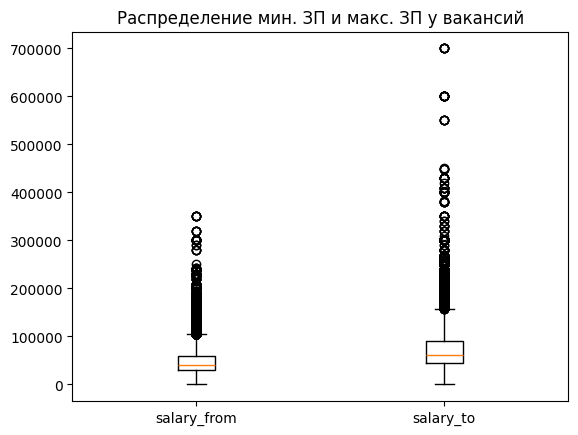

In [13]:
plt.boxplot(dataset[[sign_1, sign_2]], tick_labels=[sign_1, sign_2])
plt.title('Распределение мин. ЗП и макс. ЗП у вакансий')
plt.show()

Построим гисторграмму для признака по формуле Стёрджеса

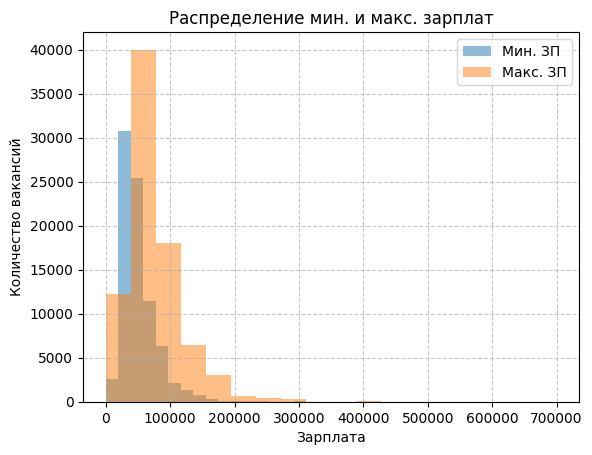

In [14]:
plt.hist(dataset[sign_1], bins='sturges', alpha=0.5, label='Мин. ЗП')
plt.hist(dataset[sign_2], bins='sturges', alpha=0.5, label='Макс. ЗП')

plt.title('Распределение мин. и макс. зарплат')
plt.xlabel('Зарплата')
plt.ylabel('Количество вакансий')
plt.legend()  # Показываем легенду с метками
plt.grid(True, linestyle='--', alpha=0.7)  # Сетка для удобства
plt.show()

Поосмотрим на коэффициент асимметрии

In [15]:
print(f"Коэффициент асимметрии {sign_1}: {stats.skew(dataset[sign_1])}")
print(f"Коэффициент асимметрии {sign_2}: {stats.skew(dataset[sign_2])}")

Коэффициент асимметрии salary_from: 2.2349798770486733
Коэффициент асимметрии salary_to: 2.4418728238636023


Посмотрим на значения у которых минимальная или максимальная ЗП меньше 100

In [16]:
dataset[(dataset[sign_1] < 100) | (dataset[sign_2] < 100)][['professional_roles', sign_1, sign_2]]

,professional_roles,salary_from,salary_to
2307,Другое,35,50
5944,"Инженер-конструктор, инженер-проектировщик",50,69
5945,"Инженер-конструктор, инженер-проектировщик",50,69
14931,Экономист,65,80
14932,Экономист,65,80
...,...,...,...
76135,Водитель,40,55000
76136,Водитель,40,55000
76137,Водитель,40,55000
76138,Водитель,40,55000


Посмотрим на значения у которых минимальная или максимальная ЗП меньше 1000, но больше 99

In [17]:
dataset[
    ((dataset[sign_1] < 1000) & (dataset[sign_1] >= 100)) |
    ((dataset[sign_2] < 1000) & (dataset[sign_2] >= 100))
][['professional_roles', sign_1, sign_2]]

,professional_roles,salary_from,salary_to
3634,Аналитик,500,97812
3635,Аналитик,500,97812
3636,Аналитик,500,97812
4826,"Менеджер по продажам, менеджер по работе с кли...",100,84520
4827,"Менеджер по продажам, менеджер по работе с кли...",100,84520
...,...,...,...
65069,Руководитель проектов,100,92771
65070,Руководитель проектов,100,92771
65071,Руководитель проектов,100,92771
65072,Руководитель проектов,100,92771


Посмотрим на значения у которых минимальная или максимальная ЗП меньше 10000, но больше 999

In [18]:
dataset[
    ((dataset[sign_1] < 10000) & (dataset[sign_1] >= 1000)) |
    ((dataset[sign_2] < 10000) & (dataset[sign_2] >= 1000))
][['professional_roles', sign_1, sign_2]]

,professional_roles,salary_from,salary_to
307,"Упаковщик, комплектовщик",1700,47937
308,"Упаковщик, комплектовщик",1700,47937
516,"Учитель, преподаватель, педагог",8000,45000
517,"Учитель, преподаватель, педагог",8000,45000
518,"Учитель, преподаватель, педагог",8000,45000
...,...,...,...
81371,"Продавец-консультант, продавец-кассир",5000,8000
81372,"Продавец-консультант, продавец-кассир",5000,8000
81373,"Продавец-консультант, продавец-кассир",5000,8000
81374,"Продавец-консультант, продавец-кассир",5000,8000


Домножим все значения меньшие 100 на 1000

In [19]:
dataset.loc[dataset[sign_1] < 100, sign_1] *= 1000
dataset.loc[dataset[sign_2] < 100, sign_2] *= 1000

Домножим все значения меньшие 1000 на 100

In [20]:
dataset.loc[dataset[sign_1] < 1000, sign_1] *= 100
dataset.loc[dataset[sign_2] < 1000, sign_2] *= 100

Домножим все значения меньшие 10000 на 10

In [21]:
dataset.loc[dataset[sign_1] < 10000, sign_1] *= 10
dataset.loc[dataset[sign_2] < 10000, sign_2] *= 10

Проверим отсутствие значение у которых минимальная ЗП меньше 10000

In [22]:
dataset[(dataset[sign_1] < 10000) | (dataset[sign_2] < 10000)]

,id,professional_roles,experience,schedule,employment,employer,accept_handicapped,key_skills,city,salary_from,salary_to,field_of_activity


Посмотрим нет ли наблюдений в которых минимальная зарплата больше, чем максимальная

In [23]:
dataset[dataset[sign_1] > dataset[sign_2]][[sign_1, sign_2]]

,salary_from,salary_to
516,80000,45000
517,80000,45000
518,80000,45000
519,80000,45000
520,80000,45000
...,...,...
78244,90000,27072
78245,90000,27072
78246,90000,27072
78247,90000,27072


Поменяем местами, если есть такие строки

In [24]:
mask = dataset[sign_1] > dataset[sign_2]
dataset.loc[mask, [sign_1, sign_2]] = dataset.loc[mask, [sign_2, sign_1]].values

Проверим нет ли теперь наблюдений в которых минимальная зарплата больше, чем максимальная

In [25]:
dataset[dataset[sign_1] > dataset[sign_2]][[sign_1, sign_2]]

,salary_from,salary_to


Рассчитаем процентили 10, 25, 50, 75, 90

In [26]:
percentile_10_value_sign_1 = dataset[sign_1].quantile(0.10)
percentile_25_value_sign_1 = dataset[sign_1].quantile(0.25)
percentile_50_value_sign_1 = dataset[sign_1].quantile(0.50)
percentile_75_value_sign_1 = dataset[sign_1].quantile(0.75)
percentile_90_value_sign_1 = dataset[sign_1].quantile(0.90)

percentile_10_value_sign_2 = dataset[sign_2].quantile(0.10)
percentile_25_value_sign_2 = dataset[sign_2].quantile(0.25)
percentile_50_value_sign_2 = dataset[sign_2].quantile(0.50)
percentile_75_value_sign_2 = dataset[sign_2].quantile(0.75)
percentile_90_value_sign_2 = dataset[sign_2].quantile(0.90)

print(f'10-й процентиль {sign_1}: {percentile_10_value_sign_1}')
print(f'25-й процентиль {sign_1}: {percentile_25_value_sign_1}')
print(f'50-й процентиль {sign_1}: {percentile_50_value_sign_1}')
print(f'75-й процентиль {sign_1}: {percentile_75_value_sign_1}')
print(f'90-й процентиль {sign_1}: {percentile_90_value_sign_1}')

print(f'10-й процентиль {sign_2}: {percentile_10_value_sign_2}')
print(f'25-й процентиль {sign_2}: {percentile_25_value_sign_2}')
print(f'50-й процентиль {sign_2}: {percentile_50_value_sign_2}')
print(f'75-й процентиль {sign_2}: {percentile_75_value_sign_2}')
print(f'90-й процентиль {sign_2}: {percentile_90_value_sign_2}')

10-й процентиль salary_from: 25000.0
25-й процентиль salary_from: 30000.0
50-й процентиль salary_from: 41000.0
75-й процентиль salary_from: 60000.0
90-й процентиль salary_from: 89624.0
10-й процентиль salary_to: 35000.0
25-й процентиль salary_to: 45000.0
50-й процентиль salary_to: 61829.0
75-й процентиль salary_to: 90000.0
90-й процентиль salary_to: 133305.0


Посмотрим значение описательной статистики

In [27]:
pd.DataFrame([dataset[sign_1].describe(), dataset[sign_2].describe()])

,count,mean,std,min,25%,50%,75%,max
salary_from,81412.0,49477.776004,28252.313001,10000.0,30000.0,41000.0,60000.0,350000.0
salary_to,81412.0,73773.182835,43973.324128,10000.0,45000.0,61829.0,90000.0,700000.0


Посмотрим сколько значений по признакам sign_1 и sign_2 больше своих 90-ых процентилей

In [28]:
dataset[(dataset[sign_1] > dataset[sign_1].quantile(0.95)) | (dataset[sign_2] > dataset[sign_2].quantile(0.95))][['professional_roles', sign_1, sign_2]]

,professional_roles,salary_from,salary_to
200,Коммерческий директор (CCO),123554,264687
201,Коммерческий директор (CCO),123554,264687
202,Коммерческий директор (CCO),123554,264687
203,Коммерческий директор (CCO),123554,264687
215,Сварщик,160000,160000
...,...,...,...
81001,"Менеджер по продажам, менеджер по работе с кли...",50000,200000
81002,"Менеджер по продажам, менеджер по работе с кли...",50000,200000
81003,"Менеджер по продажам, менеджер по работе с кли...",50000,200000
81404,Менеджер по закупкам,120000,135000


Построим диаграмму "ящик с усами" для признака

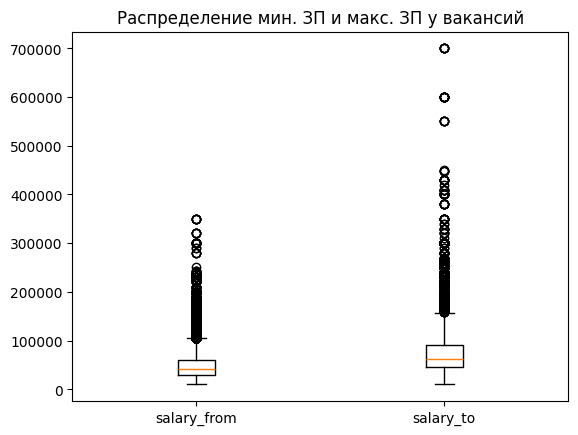

In [29]:
plt.boxplot(dataset[[sign_1, sign_2]], tick_labels=[sign_1, sign_2])
plt.title('Распределение мин. ЗП и макс. ЗП у вакансий')
plt.show()

Построим гисторграмму для признака по формуле Стёрджеса

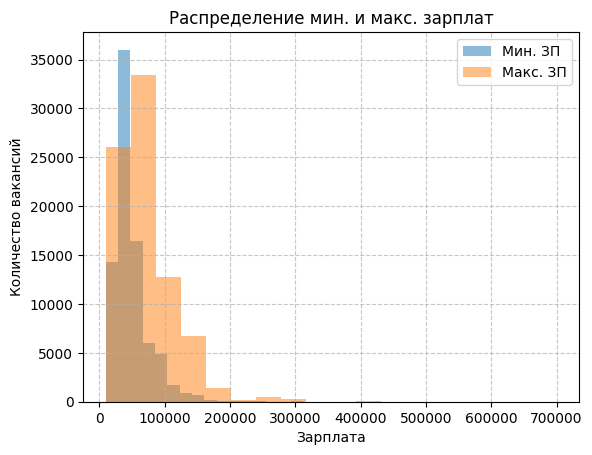

In [30]:
plt.hist(dataset[sign_1], bins='sturges', alpha=0.5, label='Мин. ЗП')
plt.hist(dataset[sign_2], bins='sturges', alpha=0.5, label='Макс. ЗП')

plt.title('Распределение мин. и макс. зарплат')
plt.xlabel('Зарплата')
plt.ylabel('Количество вакансий')
plt.legend()  # Показываем легенду с метками
plt.grid(True, linestyle='--', alpha=0.7)  # Сетка для удобства
plt.show()

Поосмотрим на коэффициент асимметрии

In [31]:
print(f"Коэффициент асимметрии {sign_1}: {stats.skew(dataset[sign_1])}")
print(f"Коэффициент асимметрии {sign_2}: {stats.skew(dataset[sign_2])}")

Коэффициент асимметрии salary_from: 2.267799511899197
Коэффициент асимметрии salary_to: 2.4582691554209752


Выводы по анализу признака:

  * О максимальных и минимальных значениях признака (размах значений)

    - salary_from: min = 10000, max = 350000

    - salary_to: min = 10000, max = 700000

    - Размах значений очень большой, что указывает на значительные различия в зарплатных предложениях.
  
  * О нулевых значениях (их наличие, нужна ли предобработка)
  
    - Нулевые значения отсутствуют

    - Разница между средним и медианой говорит о наличии выбросов или асимметрии в распределении.

  * О средних величинах (среднее, медиана, их отличия, возможные причины)

    - Среднее salary_from: 49477.776004

    - Среднее salary_to: 	73773.182835

    - Медиана salary_from: 41000

    - Медиана salary_to: 61829

    - Разница между средним и медианой говорит о наличии выбросов или асимметрии в распределении.

  * О процентилях (сколько процентов данных не превышают то или иное значение)

    - 10-й процентиль salary_from: 25000.0

    - 25-й процентиль salary_from: 30000.0

    - 50-й процентиль salary_from: 41000.0

    - 75-й процентиль salary_from: 60000.0

    - 90-й процентиль salary_from: 89624.0

    - 10-й процентиль salary_to: 35000.0

    - 25-й процентиль salary_to: 45000.0

    - 50-й процентиль salary_to: 61829.0

    - 75-й процентиль salary_to: 90000.0

    - 90-й процентиль salary_to: 133305.0

  * О результатах графического анализа (что показывает "ящик с усами", что показывает гистограмма)

    - Ящик с усами (boxplot):

      - Видны аномально высокие зарплаты (выбросы).

    - Гистограмма:

      - Распределение зарплат скошено вправо salary_from(положительная асимметрия)

      - Распределение зарплат скошено вправо salary_to(положительная асимметрия).

      - Большая часть данных salary_from сосредоточена в левой части графика.

      - Большая часть данных salary_to сосредоточена в левой части графика.

    - Коэффициент асимметрии:

      - Для salary_from: 2.267799511899197

      - Для salary_to: 2.4582691554209752

## 8. Неграфический и графический анализ категориальных признаков

Зададим базовые цвета для отображения топ 5 категорий для анализа признаков

In [32]:
colors = ('#FF9AA2', '#FFB7B2', '#FFDAC1', '#E2F0CB', '#B5EAD7')

Зададим свойства секторов (долей) круговой диаграммы

In [33]:
wedgeprops = {'linewidth': 1.5, 'edgecolor': 'white'}

Зададим свойства текста круговой диаграммы

In [34]:
textprops={'fontsize': 12}

### 8.1 Признак professional_roles

Сохраним имя признака в переменную sign

In [35]:
sign = 'professional_roles'

Оценим описательные статистики признака

In [36]:
dataset[sign].describe()

,professional_roles
count,81412
unique,171
top,Другое
freq,7302


Изучим уникальные значения признака

In [37]:
dataset[sign].unique()

<StringArray>
[          'Инженер-конструктор, инженер-проектировщик',
                                               'Курьер',
 'Менеджер по продажам, менеджер по работе с клиентами',
                            'Официант, бармен, бариста',
                              'Повар, пекарь, кондитер',
                                             'Технолог',
                                             'Водитель',
                                     'Электромонтажник',
                                'Агент по недвижимости',
                        'Делопроизводитель, архивариус',
 ...
                   'Менеджер по компенсациям и льготам',
             'Директор юридического департамента (CLO)',
                           'Технический директор (CTO)',
                    'Арт-директор, креативный директор',
                                       'Дата-сайентист',
                                             'Метролог',
                           'Специалист по сертификации',
            

Выведем количество уникальных значений

In [38]:
dataset[sign].unique().shape

(171,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [39]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts.head(30)

,count
professional_roles,
Другое,7302
"Менеджер по продажам, менеджер по работе с клиентами",6604
"Продавец-консультант, продавец-кассир",4771
Водитель,3366
Бухгалтер,2716
"Программист, разработчик",2648
"Инженер-конструктор, инженер-проектировщик",2246
Администратор,2194
Врач,1914


Сохраним 5 самых часто встречающихся значений

In [40]:
top_5_most_frequent = value_counts[:5]
top_5_most_frequent

,count
professional_roles,
Другое,7302
"Менеджер по продажам, менеджер по работе с клиентами",6604
"Продавец-консультант, продавец-кассир",4771
Водитель,3366
Бухгалтер,2716


Визуализируeм распределение 20 самых часто встречаемых значений категориального признака в виде гистограммы

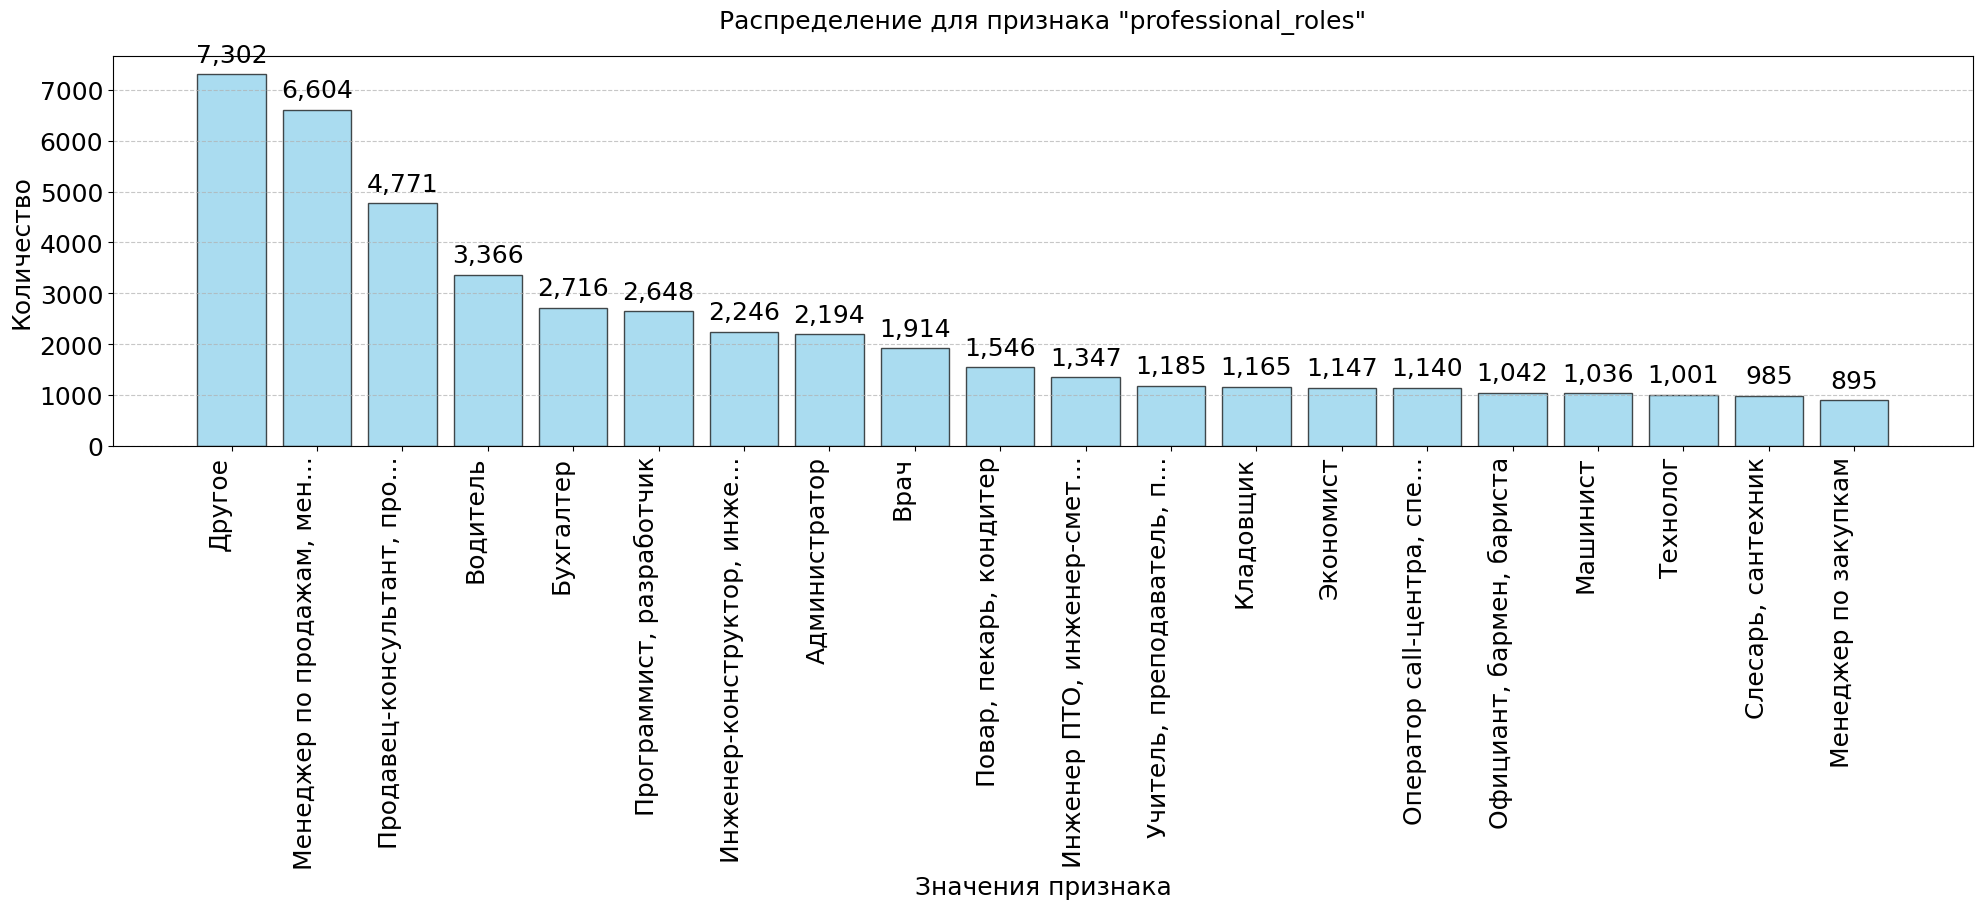

In [41]:
new_index = [str(value)[:25] + "..." if len(str(value)) > 25 else value
            for value in value_counts.index]
# Создаем фигуру и оси размером 24x8 дюймов
plt.figure(figsize=(24, 6))

# Строим столбчатую диаграмму (гистограмму)
bars = plt.bar(new_index[:20],                    # Категории по оси X (значения признака)
               value_counts[:20].values,          # Высота столбцов (количество каждого значения)
               color='skyblue',                   # Цвет столбцов
               edgecolor='black',                 # Цвет границ столбцов
               alpha=0.7,                         # Прозрачность (0-1)
)

# Добавляем подписи значений сверху каждого столбца
for bar in bars:
    height = bar.get_height()                           # Получаем высоту текущего столбца
    plt.text(bar.get_x() + bar.get_width() / 2,         # Позиция X (по центру столбца)
             height + 0.02 * max(value_counts[:20]),    # Позиция Y (немного выше вершины столбца)
             f'{height:,}',                             # Форматированное число (с разделителями тысяч)
             ha='center',                               # Горизонтальное выравнивание по центру
             va='bottom',                               # Вертикальное выравнивание по низу
             fontsize=18                                # Размер шрифта
    )

# Настройка осей и заголовка
plt.title(f'Распределение для признака "{sign}"',  # Заголовок с именем признака
          fontsize=18,                             # Размер шрифта заголовка
          pad=20                                   # Отступ заголовка от графика
)
plt.xlabel('Значения признака', fontsize=18)       # Подпись оси X
plt.ylabel('Количество', fontsize=18)              # Подпись оси Y
plt.xticks(rotation=90, ha='right', fontsize=18)   # Поворот подписей X на 90 градусов с выравниванием вправо
plt.yticks(fontsize=18)                            # Шрифт Y
plt.grid(axis='y', linestyle='--', alpha=0.7)      # Сетка только по оси Y (пунктирная, полупрозрачная)

plt.subplots_adjust(bottom=0.25, top=0.9)  # Регулируем нижний и верхний отступ

# Отображение графика
plt.show()

Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

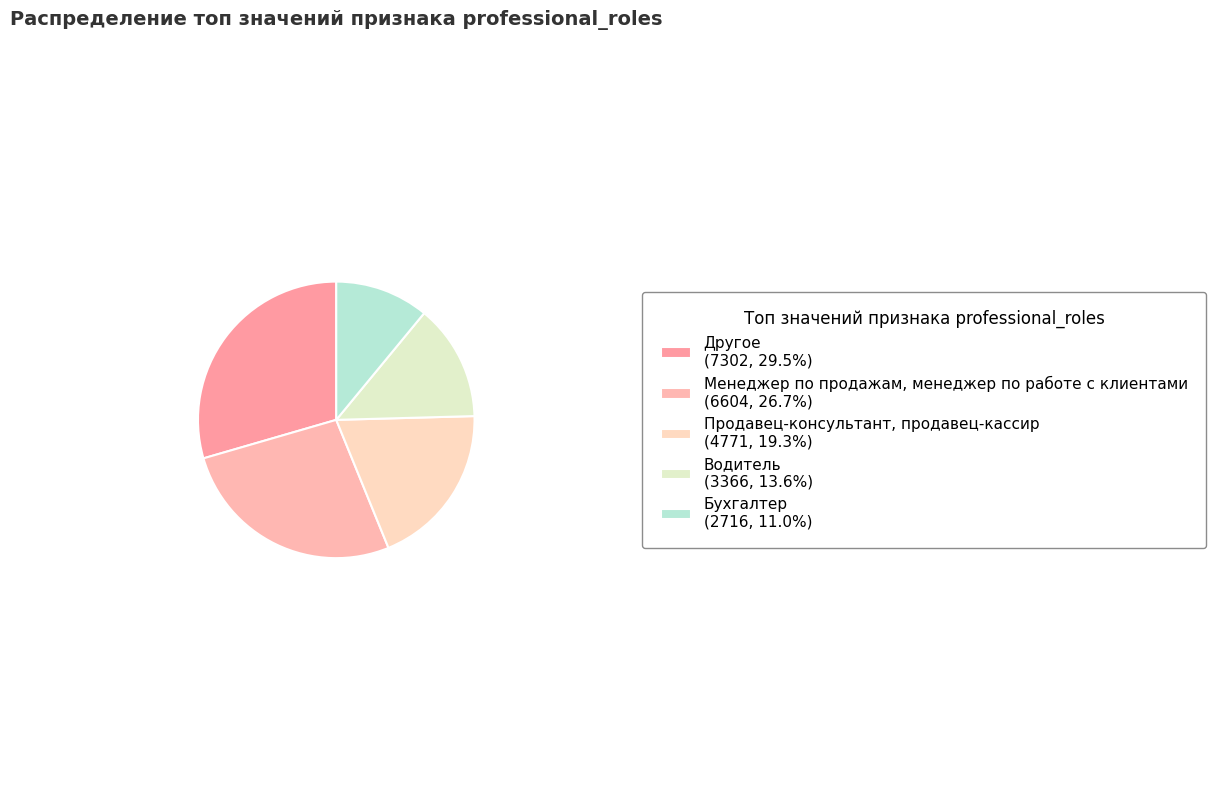

In [42]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    top_5_most_frequent,   # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = top_5_most_frequent.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in top_5_most_frequent.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        top_5_most_frequent.index,    # Названия категорий
        top_5_most_frequent.values,   # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(
    f'Распределение топ значений признака {sign}',   # Текст заголовка
    pad=25,                                            # Отступ от верха диаграммы
    fontsize=14,                                       # Размер шрифта
    fontweight='bold',                                 # Жирное начертание
    color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 171 значение

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "Другое" встретилось 7302 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - Другое:	7302

      - Менеджер по продажам, менеджер по работе с клиентами: 6604

      - Продавец консультант, продавец-кассир: 4771

      - Водитель: 3366

      - Бухгалтер:	2716

    - Наименее встречаемые:

      - Продуктовый аналитик:	6

      - Контролёр ОТК:	5

      - Менеджер по компенсациям и льготам:	5

      - Казначей:	5

      - Директор юридического департамента (CLO):	3


  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):
      
      - Другое:	7302, 29.5%

      - Менеджер по продажам, менеджер по работе с клиентами: 6604, 26.7%

      - Продавец консультант, продавец-кассир: 4771, 19.3%

      - Водитель: 3366, 13.6%

      - Бухгалтер:	2716, 11%

### 8.2 Признак experience

Сохраним имя признака в переменную sign

In [43]:
sign = 'experience'

Оценим описательные статистики признака

In [44]:
dataset[sign].describe()

,experience
count,81412
unique,4
top,1-3
freq,39313


Изучим уникальные значения признака

In [45]:
dataset[sign].unique()

['1-3', '0', '3-6', '6-']
Categories (4, object): ['0', '1-3', '3-6', '6-']

Выведем количество уникальных значений

In [46]:
dataset[sign].unique().shape

(4,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [47]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
experience,
1-3,39313
0,25731
3-6,14607
6-,1761


Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

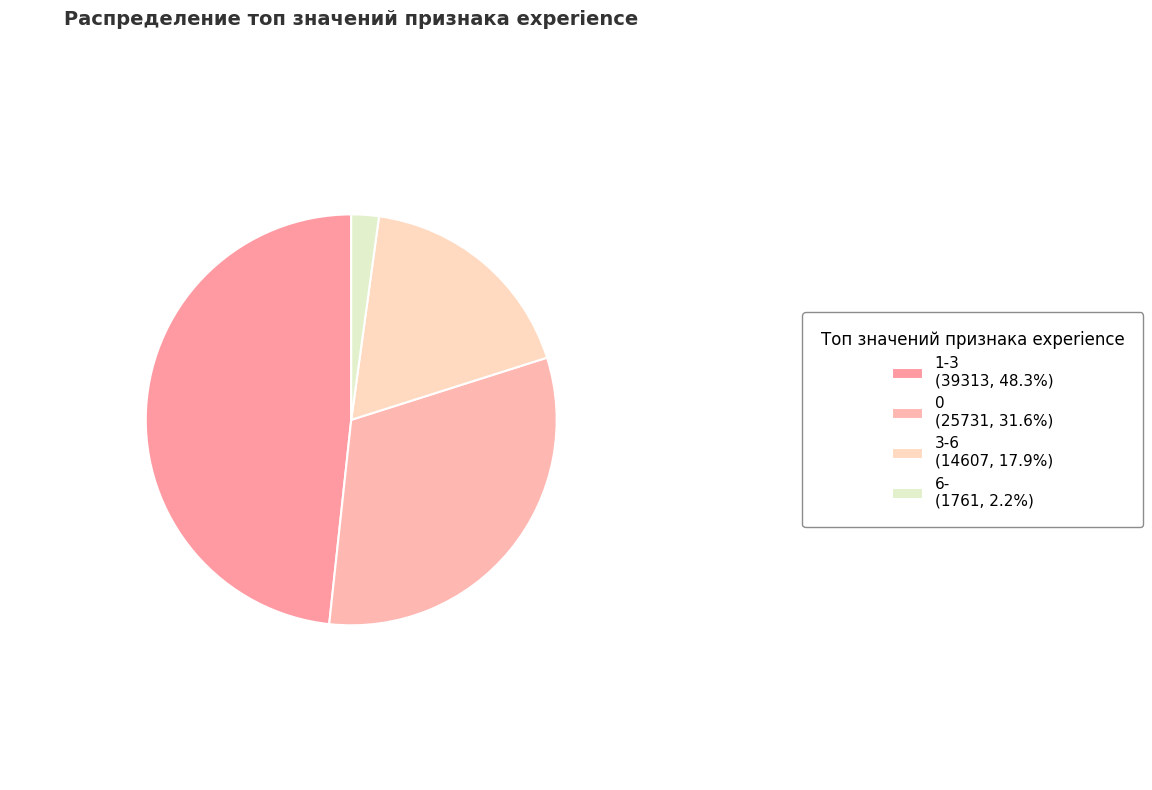

In [48]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    value_counts,          # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = value_counts.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in value_counts.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        value_counts.index,           # Названия категорий
        value_counts.values,          # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(f'Распределение топ значений признака {sign}',     # Текст заголовка
          pad=25,                                            # Отступ от верха диаграммы
          fontsize=14,                                       # Размер шрифта
          fontweight='bold',                                 # Жирное начертание
          color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 4 значения

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "1-3" встретилось 39313 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - 1-3:	39313

      - 0:	25731

    - Наименее встречаемые:

      - 3-6:	14607

      - 6-:	1761

  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

      - 1-3:	39313, 48.3%

      - 0:	25731, 31.6%

      - 3-6:	14607, 17.9%

      - 6-:	1761, 2.2%

### 8.3 Признак schedule

Сохраним имя признака в переменную sign

In [49]:
sign = 'schedule'

Оценим описательные статистики признака

In [50]:
dataset[sign].describe()

,schedule
count,81412
unique,5
top,full_day
freq,60168


Изучим уникальные значения признака

In [51]:
dataset[sign].unique()

['full_day', 'shift', 'remote', 'labor', 'flexible']
Categories (5, object): ['flexible', 'full_day', 'labor', 'remote', 'shift']

Выведем количество уникальных значений

In [52]:
dataset[sign].unique().shape

(5,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [53]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
schedule,
full_day,60168
shift,8819
labor,5948
flexible,3265
remote,3212


Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

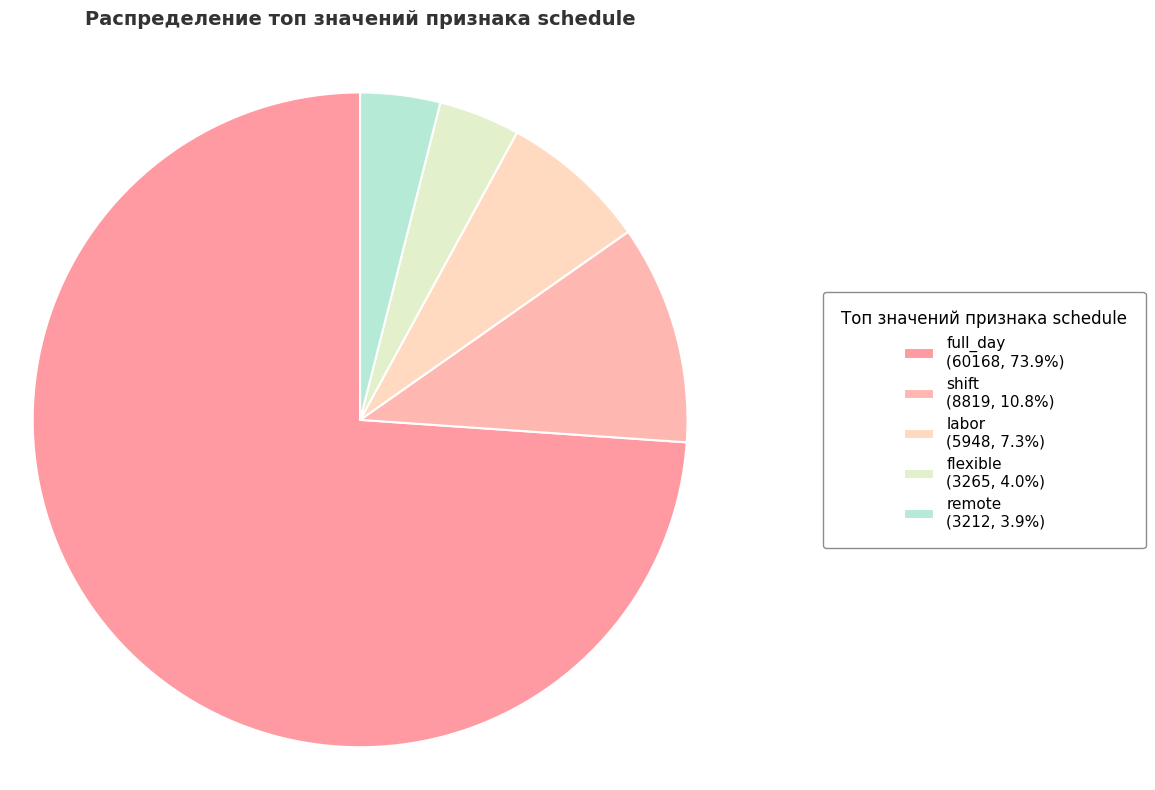

In [54]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    value_counts,          # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = value_counts.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in value_counts.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        value_counts.index,           # Названия категорий
        value_counts.values,          # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(f'Распределение топ значений признака {sign}',   # Текст заголовка
          pad=25,                                            # Отступ от верха диаграммы
          fontsize=14,                                       # Размер шрифта
          fontweight='bold',                                 # Жирное начертание
          color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 5 значений

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "full_day" встретилось 60168 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - full_day: 60168

      - shift: 8819

      - labor: 5948

    - Наименее встречаемые:

      - flexible: 3265

      - remote: 3212

  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

      - full_day: 60168, 73.9%

      - shift: 8819, 10.8%

      - labor: 5948, 7.3%

      - flexible: 3265, 4.0%

      - remote: 3212, 3.9%


### 8.4 Признак employment

Сохраним имя признака в переменную sign

In [55]:
sign = 'employment'

Оценим описательные статистики признака

In [56]:
dataset[sign].describe()

,employment
count,81412
unique,4
top,full
freq,75885


Изучим уникальные значения признака

In [57]:
dataset[sign].unique()

['full', 'part', 'project', 'probation']
Categories (4, object): ['full', 'part', 'probation', 'project']

Выведем количество уникальных значений

In [58]:
dataset[sign].unique().shape

(4,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [59]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
employment,
full,75885
part,4611
probation,622
project,294


Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

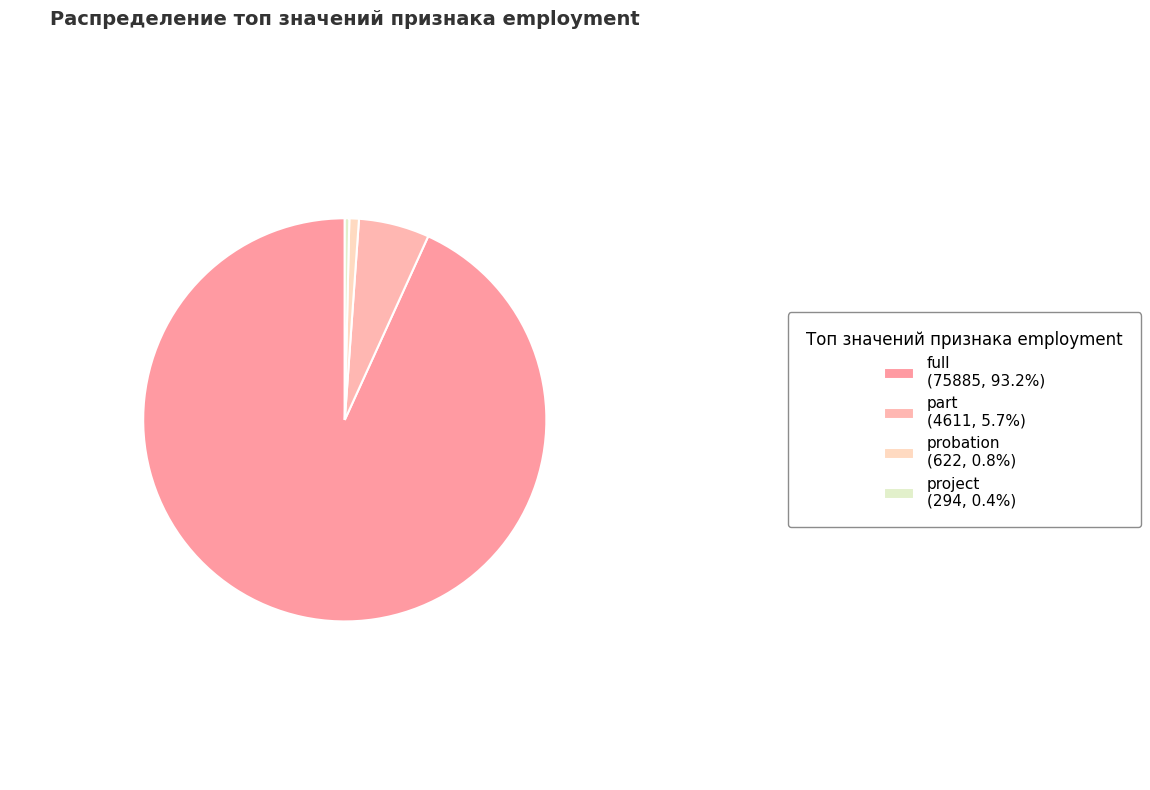

In [60]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    value_counts,          # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = value_counts.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in value_counts.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        value_counts.index,           # Названия категорий
        value_counts.values,          # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(f'Распределение топ значений признака {sign}',   # Текст заголовка
          pad=25,                                            # Отступ от верха диаграммы
          fontsize=14,                                       # Размер шрифта
          fontweight='bold',                                 # Жирное начертание
          color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 4 значения

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "full_day" встретилось 75885 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - full:	75885

      - part: 4611

    - Наименее встречаемые:

      - probation: 622

      - project: 294
  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

    - full:	75885, 93.2%

    - part: 4611, 5.7%

    - probation: 622, 0.8%

    - project: 294, 0.4%

### 8.5 Признак employer

Сохраним имя признака в переменную sign

In [61]:
sign = 'employer'

Оценим описательные статистики признака

In [62]:
dataset[sign].describe()

,employer
count,81412
unique,4394
top,Сибгарант +
freq,655


Изучим уникальные значения признака

In [63]:
dataset[sign].unique()

<StringArray>
[        'Стройкомплектсервис',                      'Квазар',
                'Staff-Linear',                   'AYS GROUP',
       'ЛАМА, Группа компаний',               'Деталь Проект',
           'Автоцентр АВТОГИК',                 'Эко-Системы',
    'Мототека, филиал г.Томск',                     'ДомПлюс',
 ...
                  'Риэлт Плюс', 'Филиппова Марина Николаевна',
                        'Вега',                 'АСС-Холдинг',
                  'Grand Line',                       'Омега',
                 'Инста Пермь',                     'Tantuni',
                  'СТОМСЕРВИС',                 'Night smoke']
Length: 4394, dtype: string

Выведем количество уникальных значений

In [64]:
dataset[sign].unique().shape

(4394,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [65]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts.head(30)

,count
employer,
Сибгарант +,655
Стройся,585
"СИБУР, Группа компаний",583
"ЛАМА, Группа компаний",449
ОГКУ ЦЗН города Томска и Томского района,381
Томский Электротехнический Завод,327
Научно-исследовательский институт полупроводниковых приборов,321
ОГКУ Облстройзаказчик,314
Научно-производственная фирма Микран,312


Сохраним 5 самых часто встречающихся значений

In [66]:
top_5_most_frequent = value_counts[:5]
top_5_most_frequent

,count
employer,
Сибгарант +,655
Стройся,585
"СИБУР, Группа компаний",583
"ЛАМА, Группа компаний",449
ОГКУ ЦЗН города Томска и Томского района,381


Визуализируeм распределение 20 самых часто встречаемых значений категориального признака в виде гистограммы

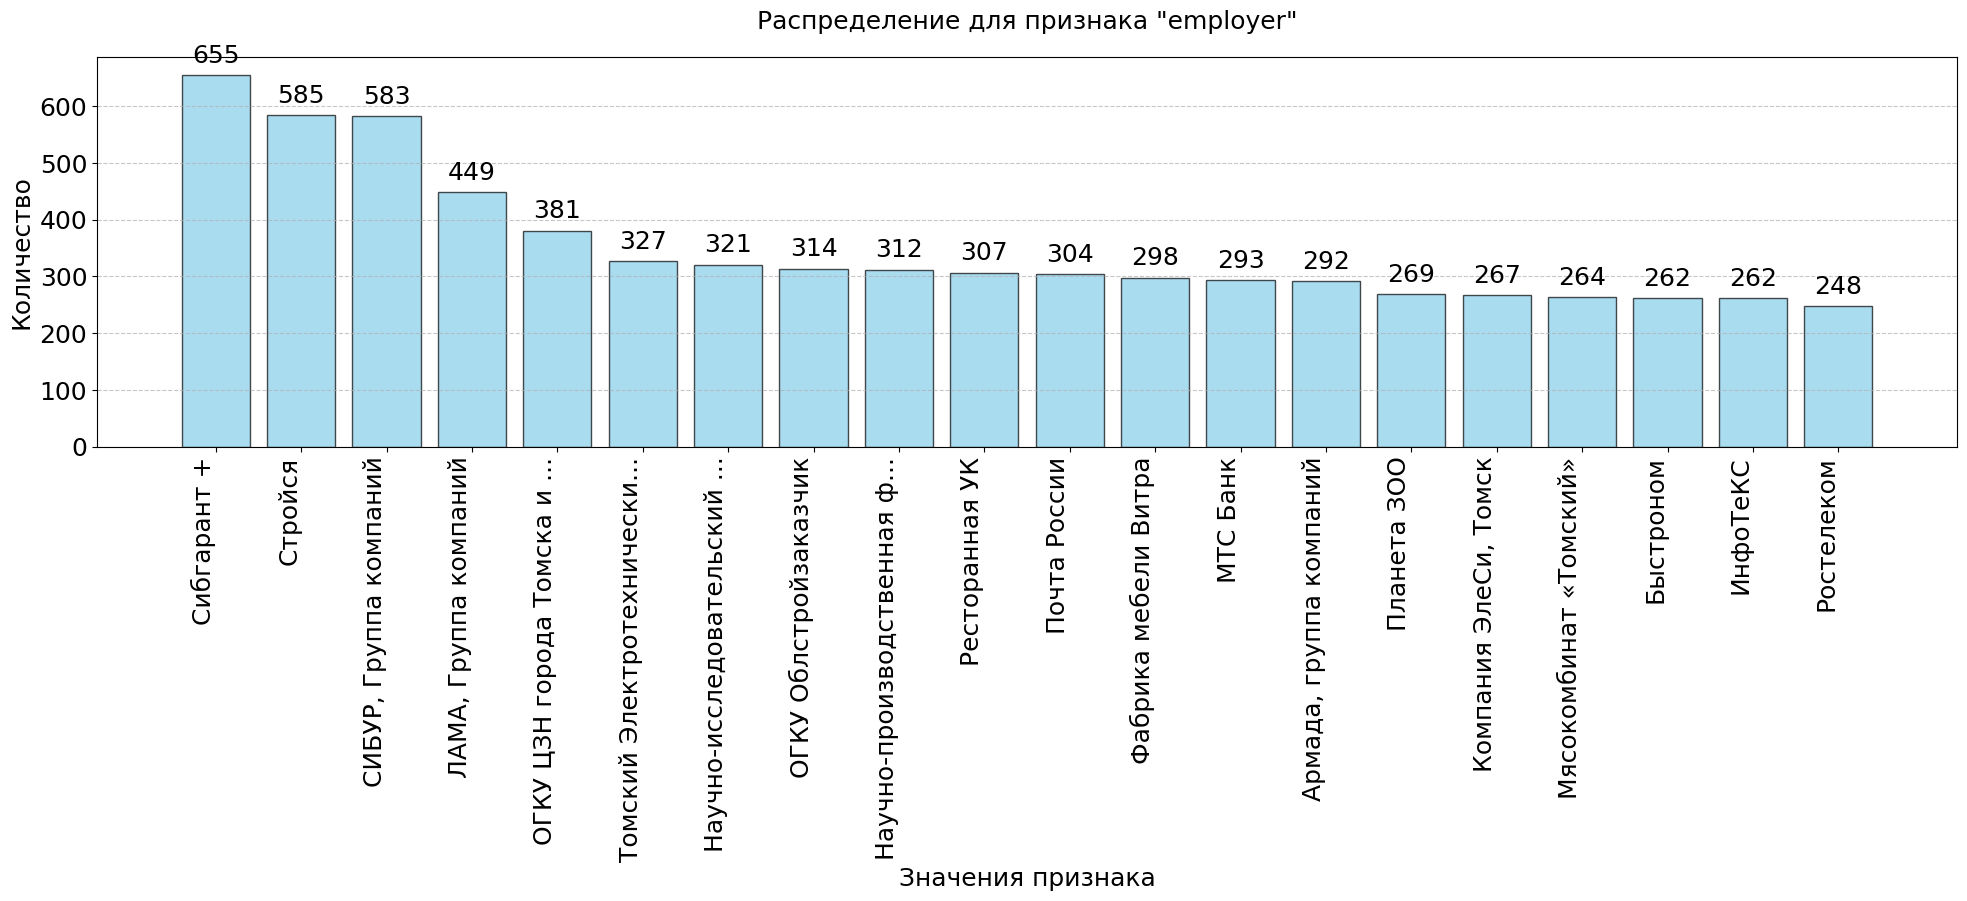

In [67]:
new_index = [str(value)[:25] + "..." if len(str(value)) > 25 else value
            for value in value_counts.index]
# Создаем фигуру и оси размером 24x8 дюймов
plt.figure(figsize=(24, 6))

# Строим столбчатую диаграмму (гистограмму)
bars = plt.bar(new_index[:20],                    # Категории по оси X (значения признака)
               value_counts[:20].values,          # Высота столбцов (количество каждого значения)
               color='skyblue',                   # Цвет столбцов
               edgecolor='black',                 # Цвет границ столбцов
               alpha=0.7,                         # Прозрачность (0-1)
)

# Добавляем подписи значений сверху каждого столбца
for bar in bars:
    height = bar.get_height()                           # Получаем высоту текущего столбца
    plt.text(bar.get_x() + bar.get_width() / 2,         # Позиция X (по центру столбца)
             height + 0.02 * max(value_counts[:20]),    # Позиция Y (немного выше вершины столбца)
             f'{height:,}',                             # Форматированное число (с разделителями тысяч)
             ha='center',                               # Горизонтальное выравнивание по центру
             va='bottom',                               # Вертикальное выравнивание по низу
             fontsize=18                                # Размер шрифта
    )

# Настройка осей и заголовка
plt.title(f'Распределение для признака "{sign}"',  # Заголовок с именем признака
          fontsize=18,                             # Размер шрифта заголовка
          pad=20                                   # Отступ заголовка от графика
)
plt.xlabel('Значения признака', fontsize=18)       # Подпись оси X
plt.ylabel('Количество', fontsize=18)              # Подпись оси Y
plt.xticks(rotation=90, ha='right', fontsize=18)   # Поворот подписей X на 90 градусов с выравниванием вправо
plt.yticks(fontsize=18)                            # Шрифт Y
plt.grid(axis='y', linestyle='--', alpha=0.7)      # Сетка только по оси Y (пунктирная, полупрозрачная)

plt.subplots_adjust(bottom=0.25, top=0.9)  # Регулируем нижний и верхний отступ

# Отображение графика
plt.show()

Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

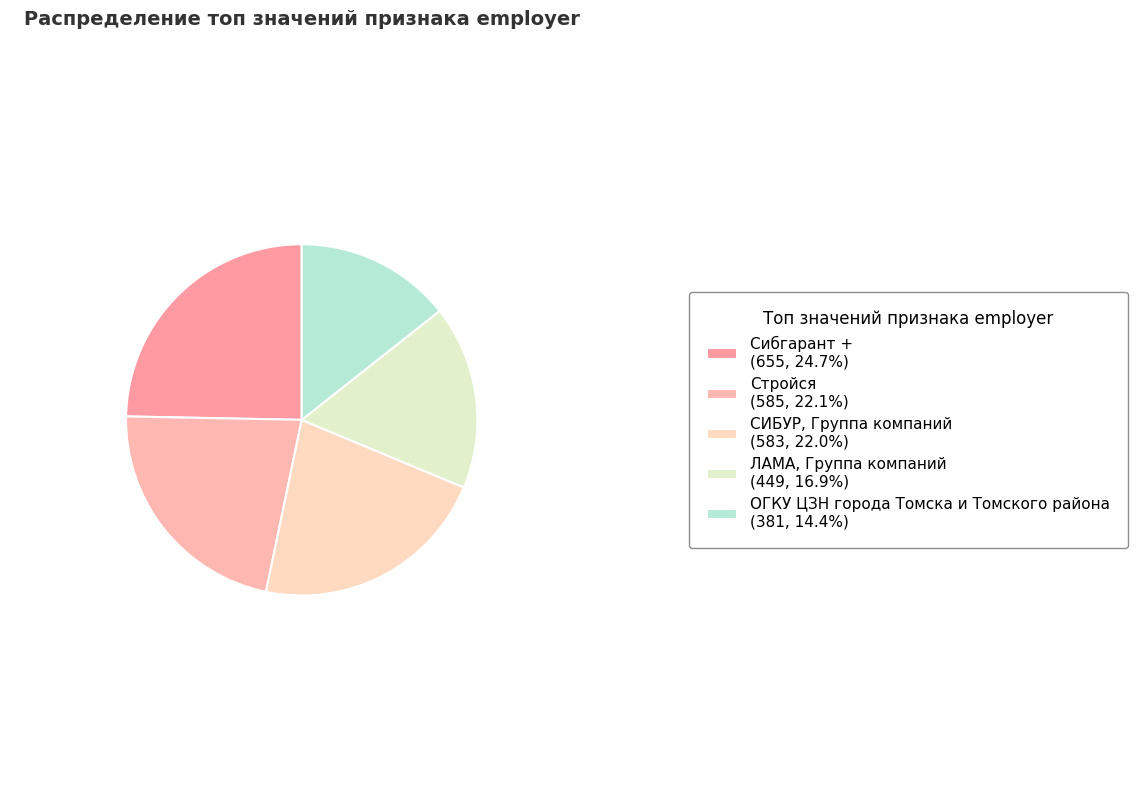

In [68]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    top_5_most_frequent,   # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = top_5_most_frequent.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in top_5_most_frequent.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        top_5_most_frequent.index,    # Названия категорий
        top_5_most_frequent.values,   # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(
    f'Распределение топ значений признака {sign}',   # Текст заголовка
    pad=25,                                            # Отступ от верха диаграммы
    fontsize=14,                                       # Размер шрифта
    fontweight='bold',                                 # Жирное начертание
    color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 4394 значений

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "Сибгарант +" встретилось 655 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - Сибгарант +: 655

      - Стройся:	585

      - Сибур.Группа компаний: 583

      - ЛАМА.Группа компаний: 449

      - ОГКУ ЦЗН города Томска и Томского района:	381
      
    - Наименее встречаемые:

      - Массажная мастерская:	1

      - РосПром Персонал:	1

      - Дело в креме:	1

      - СТОМСЕРВИС:	1

      - К-ХОЛДИНГ:	1

  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

      - Сибгарант +: 655, 24.7%

      - Стройся:	585, 22.1%

      - Сибур.Группа компаний: 583, 22%

      - ЛАМА.Группа компаний: 449, 16.9%

      - ОГКУ ЦЗН города Томска и Томского района:	381, 14.4%

### 8.6 Признак key_skills

Сохраним имя признака в переменную sign

In [69]:
sign = 'key_skills'

Оценим описательные статистики признака

In [70]:
dataset[sign].describe()

,key_skills
count,81412
unique,846
top,Работа в команде
freq,7444


Изучим уникальные значения признака

In [71]:
dataset[sign].unique()

<StringArray>
[                                  'ANSYS',
                                 'AutoCAD',
                       'Autodesk Inventor',
                              'SolidWorks',
 'Разработка конструкторской документации',
                               'КОМПАС-3D',
       'Разработка проектной документации',
                     'Разработка чертежей',
                          'Грамотная речь',
                       'Базовые знания ПК',
 ...
                              'QuickBooks',
                                  'Zeplin',
                 'Выполнение горных работ',
                                     'SAN',
               'Оценка платежеспособности',
                               'Полировка',
          'Знания в области металлографии',
                                   'KiCad',
            'Продажа легковых автомобилей',
                                '1С: ТОИР']
Length: 846, dtype: string

Выведем количество уникальных значений

In [72]:
dataset[sign].unique().shape

(846,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [73]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts.head(30)

,count
key_skills,
Работа в команде,7444
Коммуникативная грамотность,5250
Базовые знания ПК,5163
Грамотная речь,4194
Продажи,2611
Ведение документооборота,2437
Организаторские навыки,1914
Ответственность,1691
Многозадачность,1575


Сохраним 5 самых часто встречающихся навыков

In [74]:
top_5_most_frequent = value_counts[:5]
top_5_most_frequent

,count
key_skills,
Работа в команде,7444
Коммуникативная грамотность,5250
Базовые знания ПК,5163
Грамотная речь,4194
Продажи,2611


Визуализируeм распределение 20 самых часто встречаемых значений категориального признака в виде гистограммы

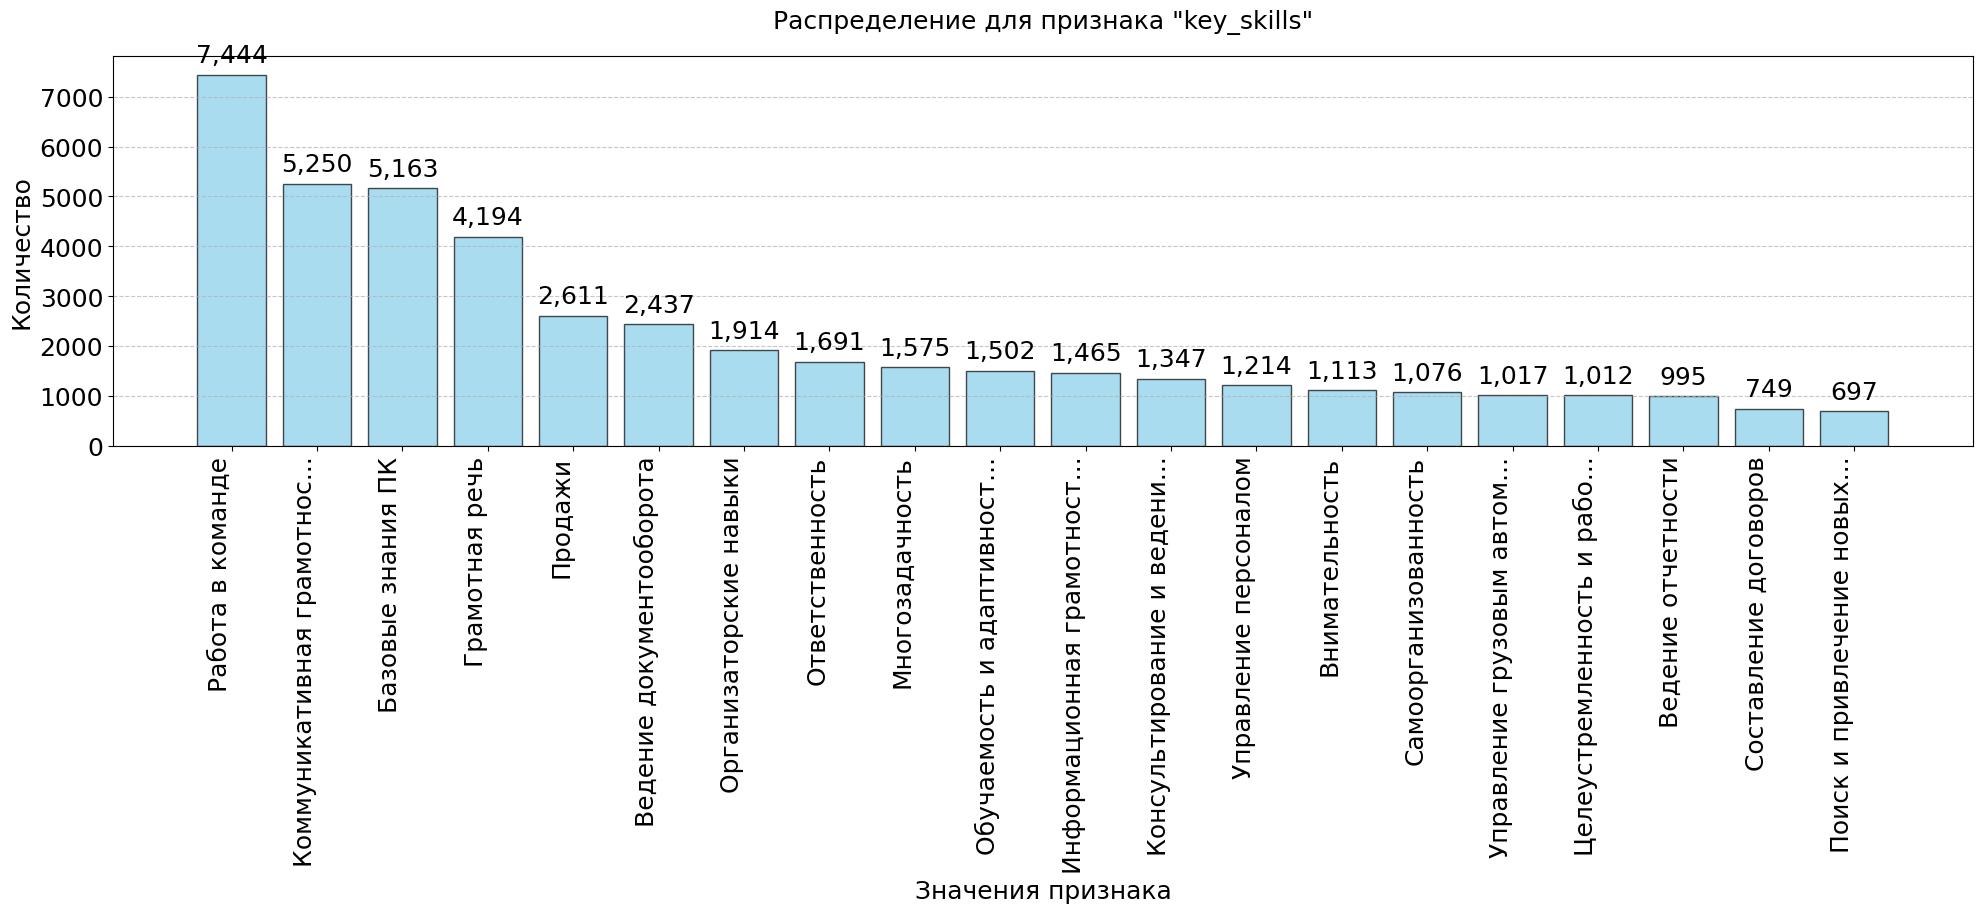

In [75]:
new_index = [str(value)[:25] + "..." if len(str(value)) > 25 else value
            for value in value_counts.index]
# Создаем фигуру и оси размером 24x8 дюймов
plt.figure(figsize=(24, 6))

# Строим столбчатую диаграмму (гистограмму)
bars = plt.bar(new_index[:20],                    # Категории по оси X (значения признака)
               value_counts[:20].values,          # Высота столбцов (количество каждого значения)
               color='skyblue',                   # Цвет столбцов
               edgecolor='black',                 # Цвет границ столбцов
               alpha=0.7,                         # Прозрачность (0-1)
)

# Добавляем подписи значений сверху каждого столбца
for bar in bars:
    height = bar.get_height()                           # Получаем высоту текущего столбца
    plt.text(bar.get_x() + bar.get_width() / 2,         # Позиция X (по центру столбца)
             height + 0.02 * max(value_counts[:20]),    # Позиция Y (немного выше вершины столбца)
             f'{height:,}',                             # Форматированное число (с разделителями тысяч)
             ha='center',                               # Горизонтальное выравнивание по центру
             va='bottom',                               # Вертикальное выравнивание по низу
             fontsize=18                                # Размер шрифта
    )

# Настройка осей и заголовка
plt.title(f'Распределение для признака "{sign}"',  # Заголовок с именем признака
          fontsize=18,                             # Размер шрифта заголовка
          pad=20                                   # Отступ заголовка от графика
)
plt.xlabel('Значения признака', fontsize=18)       # Подпись оси X
plt.ylabel('Количество', fontsize=18)              # Подпись оси Y
plt.xticks(rotation=90, ha='right', fontsize=18)   # Поворот подписей X на 90 градусов с выравниванием вправо
plt.yticks(fontsize=18)                            # Шрифт Y
plt.grid(axis='y', linestyle='--', alpha=0.7)      # Сетка только по оси Y (пунктирная, полупрозрачная)

plt.subplots_adjust(bottom=0.25, top=0.9)  # Регулируем нижний и верхний отступ

# Отображение графика
plt.show()

Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

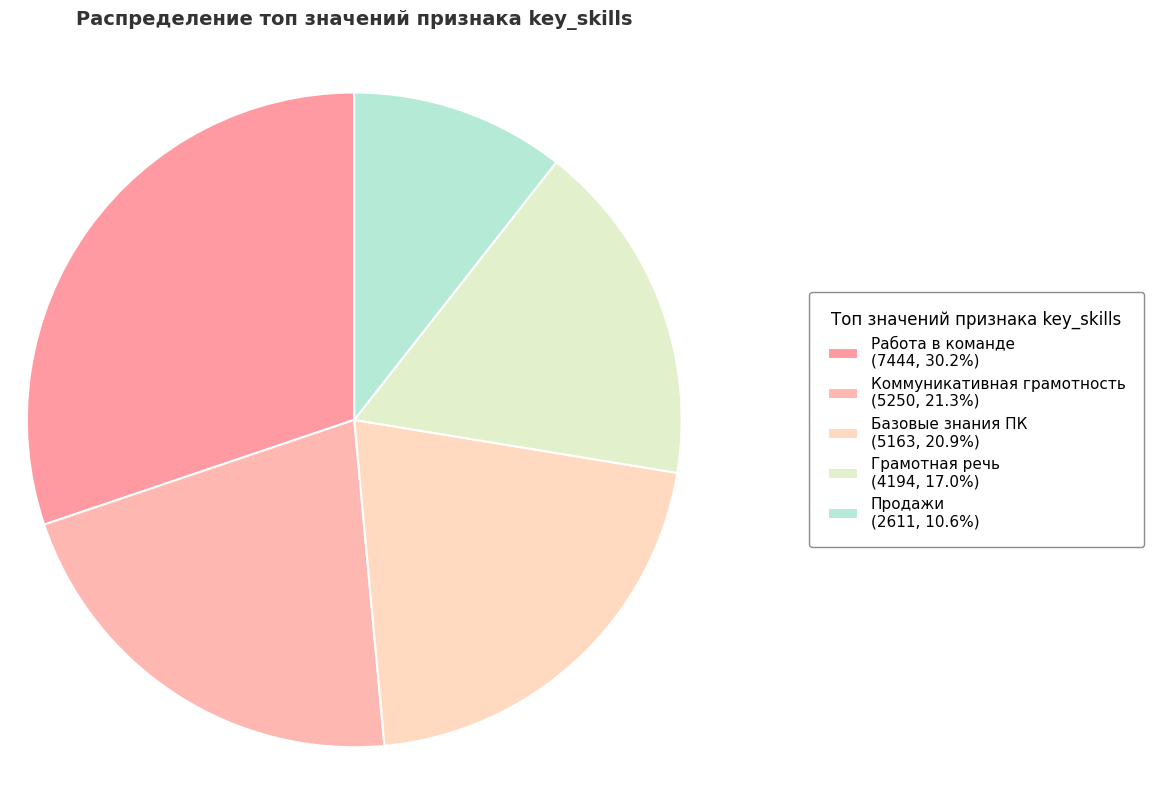

In [76]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    top_5_most_frequent,   # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = top_5_most_frequent.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in top_5_most_frequent.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        top_5_most_frequent.index,    # Названия категорий
        top_5_most_frequent.values,   # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(
    f'Распределение топ значений признака {sign}',   # Текст заголовка
    pad=25,                                            # Отступ от верха диаграммы
    fontsize=14,                                       # Размер шрифта
    fontweight='bold',                                 # Жирное начертание
    color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 846 значений

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "Работа в команде" встретилось 7444 раза

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - Работа в команде:	7444

      - Коммуникативная грамотность: 5250

      - Базовые знания ПК: 5163

      - Грамотная речь:	4194

      - Продажи: 2611

    - Наименее встречаемые:
    
      - Полировка	1

      - Знания в области металлографии	1
    
      - KiCad	1
    
      - Продажа легковых автомобилей	1
  
      - 1С: ТОИР	1




  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

      - Работа в команде:	7444, 30.2%

      - Коммуникативная грамотность: 5250, 21.3%

      - Базовые знания ПК: 5163, 20.9%

      - Грамотная речь:	4194, 17.0%

      - Продажи: 2611, 10.6%

### 8.7 Признак accept_handicapped

Сохраним имя признака в переменную sign

In [77]:
sign = 'accept_handicapped'

Оценим описательные статистики признака

In [78]:
dataset[sign].describe()

,accept_handicapped
count,81412
unique,2
top,0
freq,79998


Изучим уникальные значения признака

In [79]:
dataset[sign].unique()

['0', '1']
Categories (2, object): ['0', '1']

Выведем количество уникальных значений

In [80]:
dataset[sign].unique().shape

(2,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [81]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
accept_handicapped,
0,79998
1,1414


Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

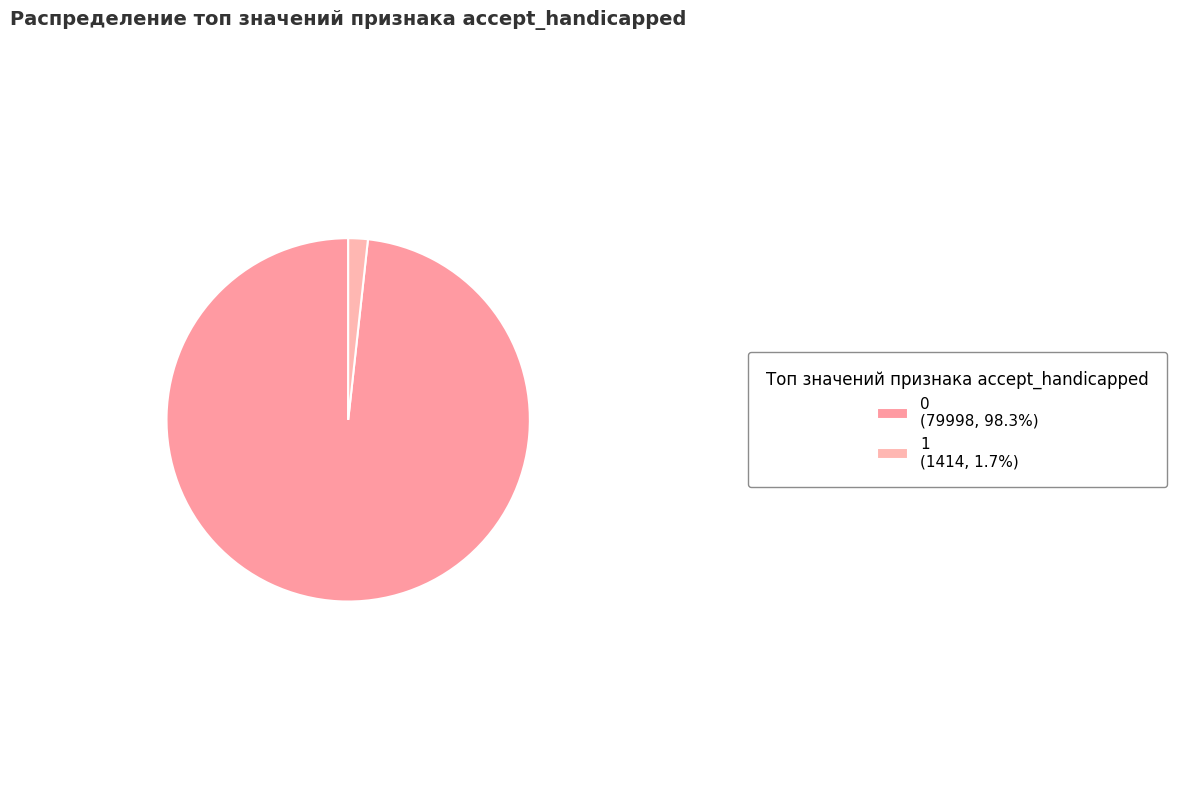

In [82]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    value_counts,          # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = value_counts.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in value_counts.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        value_counts.index,           # Названия категорий
        value_counts.values,          # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(f'Распределение топ значений признака {sign}',   # Текст заголовка
          pad=25,                                            # Отступ от верха диаграммы
          fontsize=14,                                       # Размер шрифта
          fontweight='bold',                                 # Жирное начертание
          color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 2 значения

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "0" встретилось 79998 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - 0:	79998

    - Наименее встречаемые:

      - 1: 1414



  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

    - 0:	79998, 98.3%

    - 1: 1414, 1.7%

### 8.8 Признак city

Сохраним имя признака в переменную sign

In [83]:
sign = 'city'

Оценим описательные статистики признака

In [84]:
dataset[sign].describe()

,city
count,81412
unique,42
top,Томск
freq,74319


Изучим уникальные значения признака

In [85]:
dataset[sign].unique()

<StringArray>
[                            'Томск',                          'Могочино',
                           'Каргала',    'Первомайское (Томская область)',
                           'Чажемто',                            'Самусь',
                         'Колпашево',                          'Рыбалово',
                            'Парбиг',                          'Копылово',
                            'Курлек',                          'Кедровый',
                        'Кривошеино',                          'Кисловка',
                            'Бакчар',                          'Богашёво',
         'Северск (Томская область)',         'Светлый (Томская область)',
                         'Стрежевой',                          'Белый Яр',
                         'Молчаново',                         'Подгорное',
                        'Мельниково',                             'Асино',
                          'Каргасок',                         'Тегульдет',
           

Выведем количество уникальных значений

In [86]:
dataset[sign].unique().shape

(42,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [87]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
city,
Томск,74319
Северск (Томская область),3081
Стрежевой,1001
Асино,396
Колпашево,337
Первомайское (Томская область),181
Зональная Станция,152
Светлый (Томская область),150
Парабель,136


Сохраним 5 самых часто встречающихся значений

In [88]:
top_5_most_frequent = value_counts[:5]
top_5_most_frequent

,count
city,
Томск,74319
Северск (Томская область),3081
Стрежевой,1001
Асино,396
Колпашево,337


Визуализируeм распределение 20 самых часто встречаемых значений категориального признака в виде гистограммы

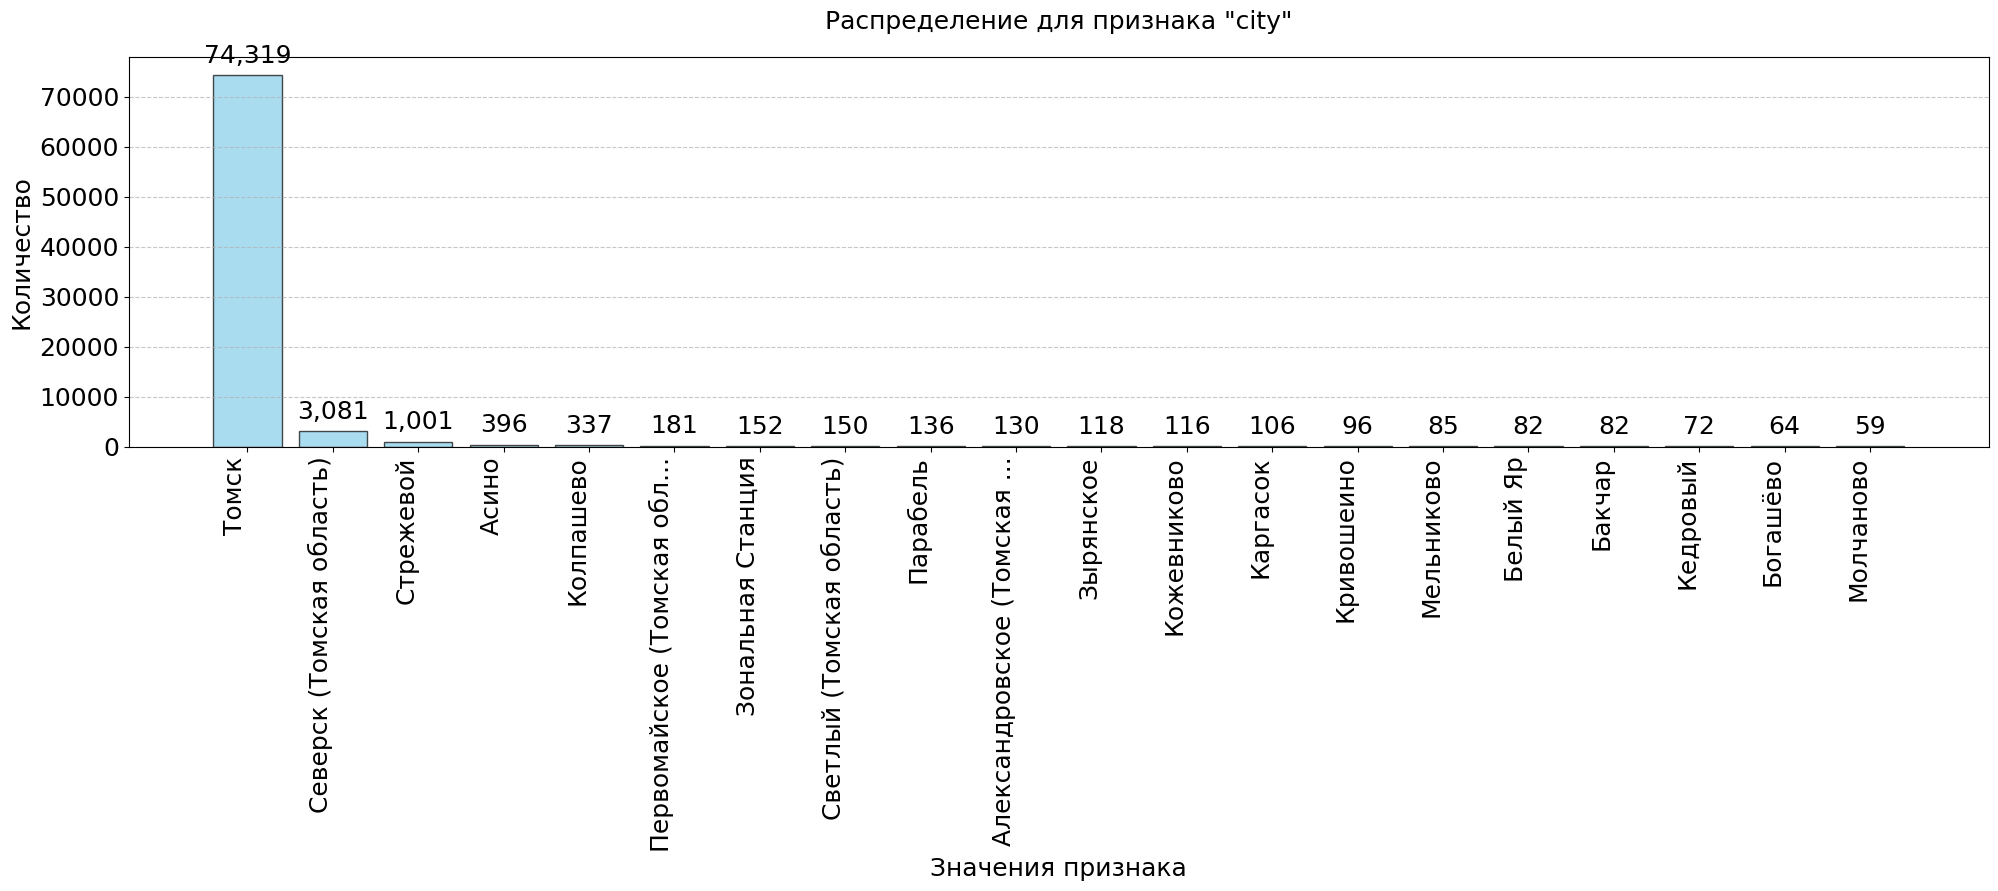

In [89]:
new_index = [str(value)[:25] + "..." if len(str(value)) > 25 else value
            for value in value_counts.index]
# Создаем фигуру и оси размером 24x8 дюймов
plt.figure(figsize=(24, 6))

# Строим столбчатую диаграмму (гистограмму)
bars = plt.bar(new_index[:20],                    # Категории по оси X (значения признака)
               value_counts[:20].values,          # Высота столбцов (количество каждого значения)
               color='skyblue',                   # Цвет столбцов
               edgecolor='black',                 # Цвет границ столбцов
               alpha=0.7,                         # Прозрачность (0-1)
)

# Добавляем подписи значений сверху каждого столбца
for bar in bars:
    height = bar.get_height()                           # Получаем высоту текущего столбца
    plt.text(bar.get_x() + bar.get_width() / 2,         # Позиция X (по центру столбца)
             height + 0.02 * max(value_counts[:20]),    # Позиция Y (немного выше вершины столбца)
             f'{height:,}',                             # Форматированное число (с разделителями тысяч)
             ha='center',                               # Горизонтальное выравнивание по центру
             va='bottom',                               # Вертикальное выравнивание по низу
             fontsize=18                                # Размер шрифта
    )

# Настройка осей и заголовка
plt.title(f'Распределение для признака "{sign}"',  # Заголовок с именем признака
          fontsize=18,                             # Размер шрифта заголовка
          pad=20                                   # Отступ заголовка от графика
)
plt.xlabel('Значения признака', fontsize=18)       # Подпись оси X
plt.ylabel('Количество', fontsize=18)              # Подпись оси Y
plt.xticks(rotation=90, ha='right', fontsize=18)   # Поворот подписей X на 90 градусов с выравниванием вправо
plt.yticks(fontsize=18)                            # Шрифт Y
plt.grid(axis='y', linestyle='--', alpha=0.7)      # Сетка только по оси Y (пунктирная, полупрозрачная)

plt.subplots_adjust(bottom=0.25, top=0.9)  # Регулируем нижний и верхний отступ

# Отображение графика
plt.show()

Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

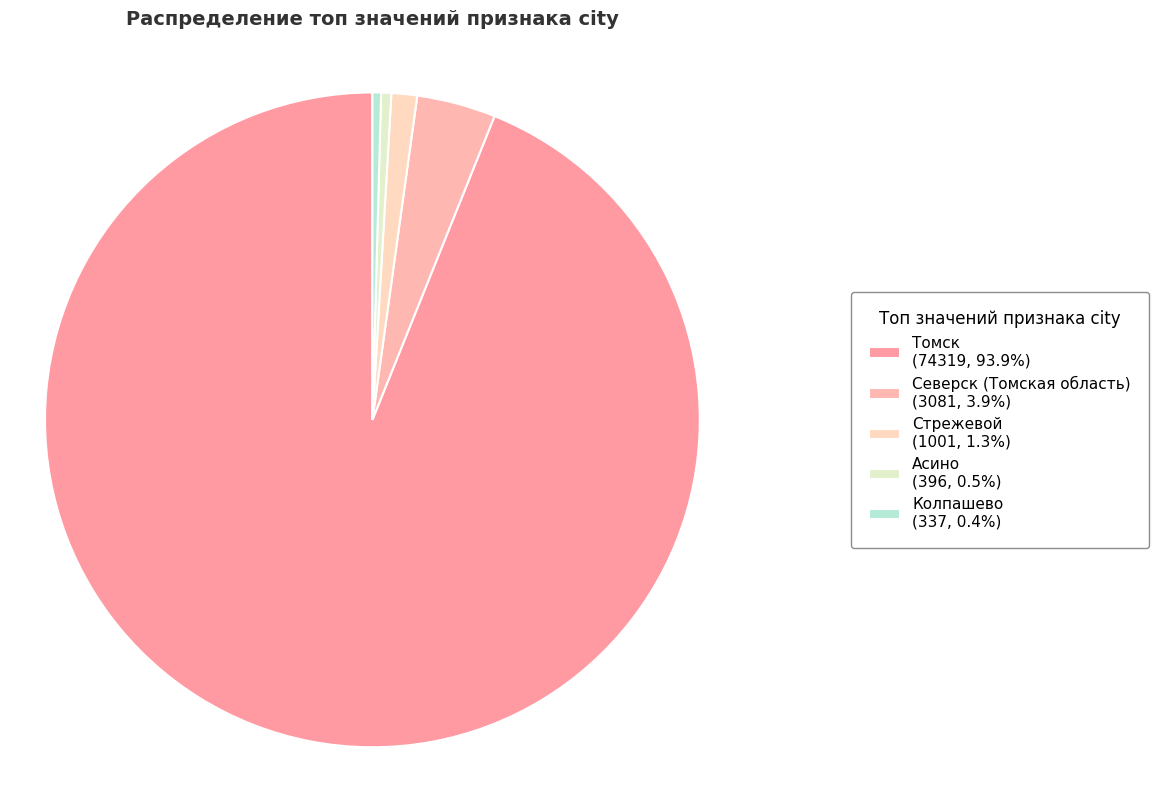

In [90]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    top_5_most_frequent,   # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = top_5_most_frequent.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in top_5_most_frequent.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        top_5_most_frequent.index,    # Названия категорий
        top_5_most_frequent.values,   # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(
    f'Распределение топ значений признака {sign}',   # Текст заголовка
    pad=25,                                            # Отступ от верха диаграммы
    fontsize=14,                                       # Размер шрифта
    fontweight='bold',                                 # Жирное начертание
    color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 42 значения

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "Томск" встретилось 74319 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - Томск:	74319

      - Северск: 3081

      - Стрежевой: 1001

      - Асино: 396

      - Колпашево:	337

    - Наименее встречаемые:

      - Каргала	14

      - Нарга	14

      - Батурино	13

      - Катайга	11

      - Степановка	5

  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):
      
      - Томск:	74319, 93.9%

      - Северск: 3081, 3.9%

      - Стрежевой: 1001, 1.3%

      - Асино: 396, 0.5%

      - Колпашево:	337, 0.4%

### 8.9 Признак field_of_activity

Сохраним имя признака в переменную sign

In [91]:
sign = 'field_of_activity'

Оценим описательные статистики признака

In [92]:
dataset[sign].describe()

,field_of_activity
count,81412
unique,20
top,Торговля и продажи
freq,15586


Изучим уникальные значения признака

In [93]:
dataset[sign].unique()

['Инженерия и строительство', 'Транспорт и логистика', 'Торговля и продажи', 'Сфера обслуживания', 'Производство и технические специальности', ..., 'Образование и наука', 'Аналитика и исследования', 'Туризм', 'Сельское хозяйство', 'Спорт и фитнес']
Length: 20
Categories (20, object): ['IT и технологии', 'Аналитика и исследования', 'Бытовые услуги',
                          'Другие сферы', ..., 'Туризм', 'Управление и администрирование',
                          'Финансы и бухгалтерия', 'Юриспруденция и безопасность']

Выведем количество уникальных значений

In [94]:
dataset[sign].unique().shape

(20,)

Проведём неграфический структурный анализ. Сохраним результаты работы метода отсортировав значения.

In [95]:
value_counts = dataset[sign].value_counts().sort_values(ascending=False)
value_counts

,count
field_of_activity,
Торговля и продажи,15586
Инженерия и строительство,9292
Сфера обслуживания,7322
Другие сферы,7302
Управление и администрирование,5902
Транспорт и логистика,5860
Производство и технические специальности,5347
IT и технологии,4988
Финансы и бухгалтерия,4616


Сохраним 5 самых часто встречающихся значений

In [96]:
top_5_most_frequent = value_counts[:5]
top_5_most_frequent

,count
field_of_activity,
Торговля и продажи,15586
Инженерия и строительство,9292
Сфера обслуживания,7322
Другие сферы,7302
Управление и администрирование,5902


Визуализируeм распределение 20 значений категориального признака в виде гистограммы

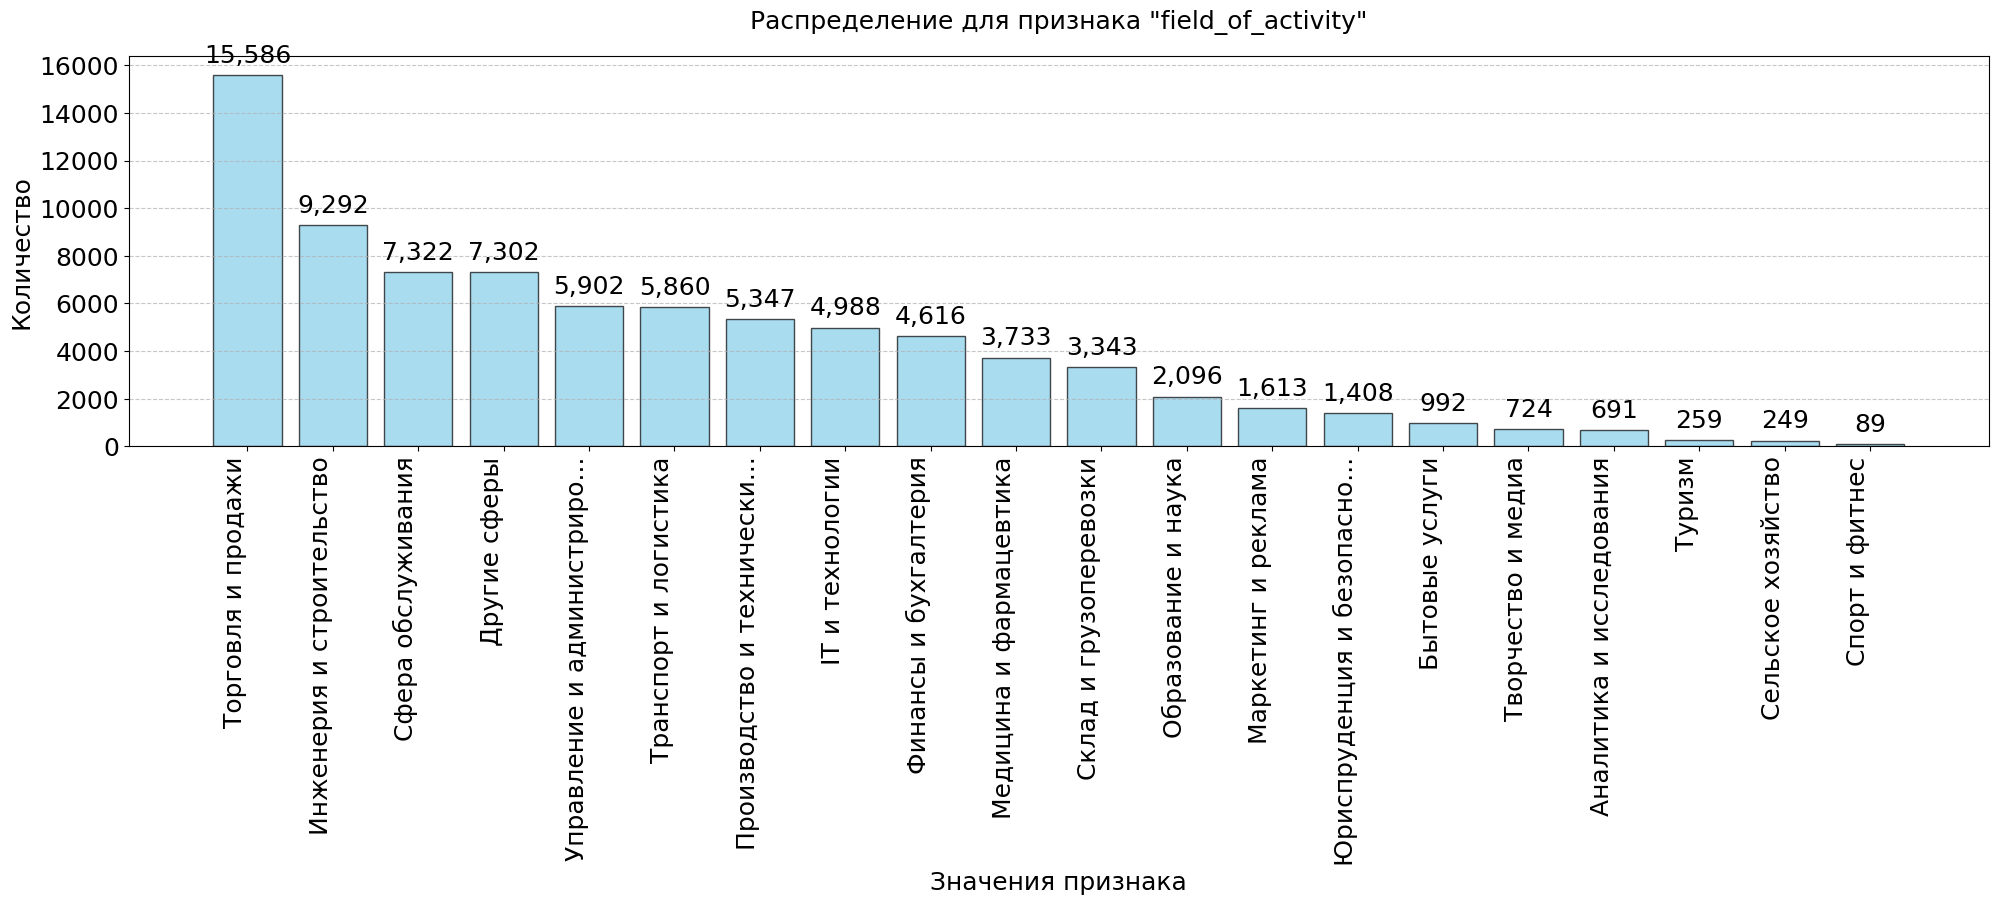

In [97]:
new_index = [str(value)[:25] + "..." if len(str(value)) > 25 else value
            for value in value_counts.index]
# Создаем фигуру и оси размером 24x8 дюймов
plt.figure(figsize=(24, 6))

# Строим столбчатую диаграмму (гистограмму)
bars = plt.bar(new_index[:20],                    # Категории по оси X (значения признака)
               value_counts[:20].values,          # Высота столбцов (количество каждого значения)
               color='skyblue',                   # Цвет столбцов
               edgecolor='black',                 # Цвет границ столбцов
               alpha=0.7,                         # Прозрачность (0-1)
)

# Добавляем подписи значений сверху каждого столбца
for bar in bars:
    height = bar.get_height()                           # Получаем высоту текущего столбца
    plt.text(bar.get_x() + bar.get_width() / 2,         # Позиция X (по центру столбца)
             height + 0.02 * max(value_counts[:20]),    # Позиция Y (немного выше вершины столбца)
             f'{height:,}',                             # Форматированное число (с разделителями тысяч)
             ha='center',                               # Горизонтальное выравнивание по центру
             va='bottom',                               # Вертикальное выравнивание по низу
             fontsize=18                                # Размер шрифта
    )

# Настройка осей и заголовка
plt.title(f'Распределение для признака "{sign}"',  # Заголовок с именем признака
          fontsize=18,                             # Размер шрифта заголовка
          pad=20                                   # Отступ заголовка от графика
)
plt.xlabel('Значения признака', fontsize=18)       # Подпись оси X
plt.ylabel('Количество', fontsize=18)              # Подпись оси Y
plt.xticks(rotation=90, ha='right', fontsize=18)   # Поворот подписей X на 90 градусов с выравниванием вправо
plt.yticks(fontsize=18)                            # Шрифт Y
plt.grid(axis='y', linestyle='--', alpha=0.7)      # Сетка только по оси Y (пунктирная, полупрозрачная)

plt.subplots_adjust(bottom=0.25, top=0.9)  # Регулируем нижний и верхний отступ

# Отображение графика
plt.show()

Визуализируем распределение топ значений категориального признака в виде круговой диаграммы с вынесенными значениями в легенду.

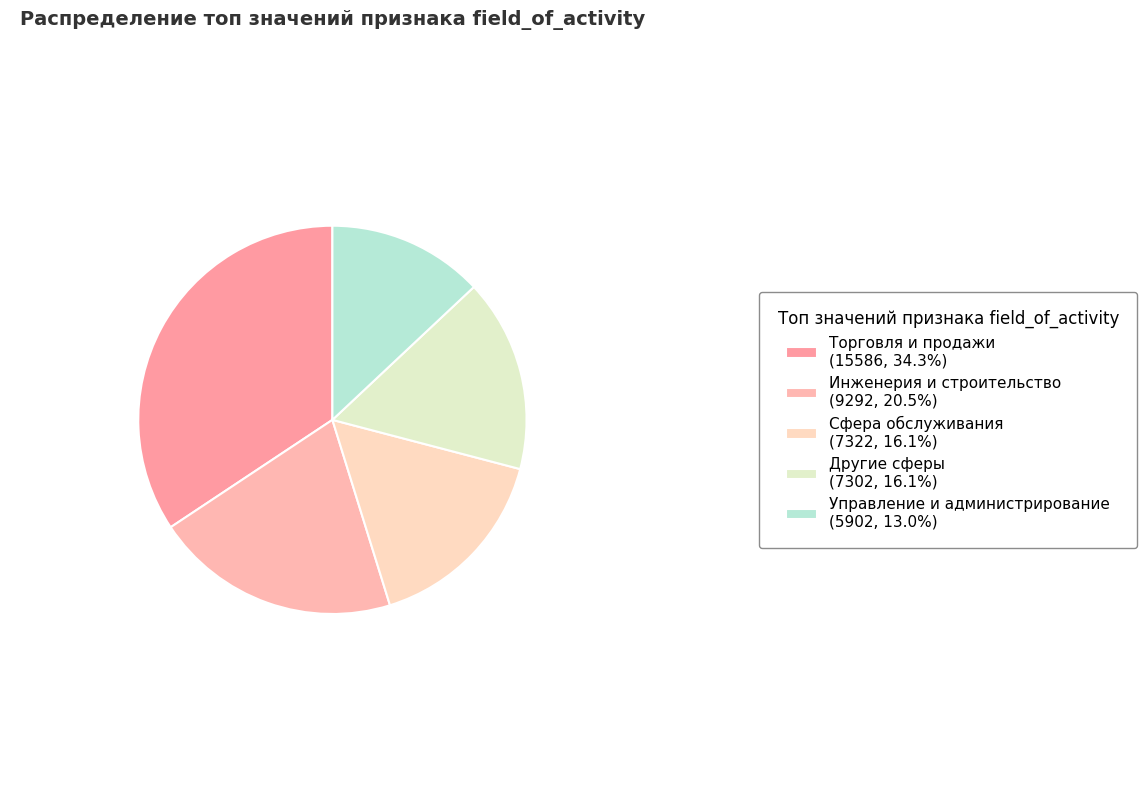

In [98]:
# Создаем круговую диаграмму и получаем 3 набора объектов:
# patches - сектора диаграммы, texts - текстовые элементы (здесь пустые), autotexts - проценты (здесь пустые)

fig, ax = plt.subplots(figsize=(12, 8))

patches, texts, autotexts = plt.pie(
    top_5_most_frequent,   # Данные для отображения (топ частых значений)
    labels=None,           # Не показываем стандартные подписи (будем использовать легенду)
    autopct='',            # Не показываем проценты внутри секторов (добавим в легенду)
    startangle=90,         # Начальный угол поворота (90° = начало сверху)
    colors=colors,         # Цвета для секторов
    wedgeprops=wedgeprops, # Свойства секторов (границы и т.д.)
    textprops=textprops,   # Свойства текста (размер шрифта)
)

# Рассчитываем общее количество (для вычисления процентов)
total = top_5_most_frequent.sum()

# Создаем список процентных соотношений с форматированием (1 знак после запятой)
percentages = [f'{(count/total)*100:.1f}%' for count in top_5_most_frequent.values]

# Формируем подписи для легенды в формате:
# Название категории
# (Абсолютное значение, Процентное соотношение)
legend_labels = [
    f'{label}\n({count}, {percent})'  # \n - перенос строки
    for label, count, percent in zip(
        top_5_most_frequent.index,    # Названия категорий
        top_5_most_frequent.values,   # Абсолютные значения
        percentages                   # Процентные соотношения
    )
]

# Создаем легенду с кастомными подписями
legend = plt.legend(patches,                                               # Сектора диаграммы (для отображения цветных маркеров)
                    legend_labels,                                         # Сформированные подписи
                    title=f"Топ значений признака {sign}",                 # Заголовок легенды
                    loc="center left",                                     # Позиционирование относительно диаграммы
                    bbox_to_anchor=(1.15, 0.5),                            # Смещение легенды (вправо на 15% от ширины)
                    fontsize=11,                                           # Размер шрифта подписей
                    title_fontsize=12,                                     # Размер шрифта заголовка
                    framealpha=0.9,                                        # Прозрачность фона легенды
                    edgecolor='gray',                                      # Цвет границы легенды
                    borderpad=1.2                                          # Отступ внутри легенды
)

# Добавляем заголовок диаграммы
plt.title(
    f'Распределение топ значений признака {sign}',   # Текст заголовка
    pad=25,                                            # Отступ от верха диаграммы
    fontsize=14,                                       # Размер шрифта
    fontweight='bold',                                 # Жирное начертание
    color='#333333'                                    # Цвет текста (темно-серый)
)

# Делаем диаграмму идеально круглой (без искажений)
plt.axis('equal')

# Автоматически регулируем отступы для предотвращения обрезания элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Выводы по анализу признака:

  * О количестве уникальных значений признака:

    - 20 значений

  * О наиболее часто встречаемом значении признака (что за значение, сколько раз встретилось):

    - значение признака "Торговля и продажи" встретилось 15586 раз

  * О распределении значений признака (наиболее встречаемые, наименее встречаемые):

    - Наиболее встречаемые:

      - Торговля и продажи: 15586

      - Инженерия и строительство: 9292

    - Наименее встречаемые:

      - Сфера обслуживания: 7322

      - Другие сферы: 7302

      - Управление и администрирование:	5902


  
  * О результатах графического анализа определенного топ признака (что показывает круговая диаграмма):

    - Торговля и продажи: 15586, 34.3%

    - Инженерия и строительство: 9292, 20.5%

    - Сфера обслуживания: 7322, 16.1%

    - Другие сферы: 7302, 16.1%

    - Управление и администрирование:	5902, 13%